# mtDSB x Age DE analysis (pydeseq2, LRT-free)

In [6]:
import os
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
from statsmodels.stats.multitest import multipletests

import pandas as pd
import numpy as np
import scipy.sparse as sp
from collections import defaultdict

def _to_dense(X):
    return X.toarray() if sp.issparse(X) else np.asarray(X)

def pseudobulk_by(
    adata,
    groupby=["cell_class", "region", "age", "condition"],
    layer=None,
    min_cells=30,
):
    """
    Create pseudobulk counts per unique combination of the groupby factors.

    Returns:
        pb_dict[cell_class][(region, age)] = (counts_df, meta_df)
        - counts_df: genes x pseudobulk-samples
        - meta_df:   rows = pseudobulk-samples (index = pb_key), cols = groupby fields
    """
    X = _to_dense(adata.layers[layer] if layer else adata.X)
    obs = adata.obs.copy()
    genes = adata.var_names

    # Build a stable pseudobulk key
    obs["pb_key"] = obs[groupby].astype(str).agg("__".join, axis=1)

    # Sum counts per pseudobulk key
    summed = (
        pd.DataFrame(X, index=obs["pb_key"], columns=genes)
        .groupby(level=0)
        .sum()
    )

    # Group metadata (indexed by pb_key already)
    meta = obs[groupby + ["pb_key"]].drop_duplicates("pb_key").set_index("pb_key")

    pb = defaultdict(dict)
    for key, row in meta.iterrows():
        cell_class = row["cell_class"]
        reg = row["region"]
        age = str(row["age"])

        # one pseudobulk column for this (cell_class, region, age, condition)
        counts_col = summed.loc[[key]].T
        counts_col.columns = [key]

        # pull the corresponding one-row metadata frame (indexed by pb_key)
        meta_row = meta.loc[[key]]

        if (reg, age) in pb[cell_class]:
            counts_df_all, meta_df = pb[cell_class][(reg, age)]
            counts_df_all = pd.concat([counts_df_all, counts_col], axis=1)
            meta_df = pd.concat([meta_df, meta_row], axis=0)
        else:
            counts_df_all = counts_col
            meta_df = meta_row

        pb[cell_class][(reg, age)] = (counts_df_all, meta_df)

    # Optional: drop group slots with too few cells total
    # (counts of cells in obs, not number of pseudobulk samples)
    to_prune = []
    for cl in list(pb.keys()):
        for (reg, age), (counts_df, meta_df) in list(pb[cl].items()):
            n_cells = (
                (obs["cell_class"] == cl)
                & (obs["region"] == reg)
                & (obs["age"].astype(str) == age)
            ).sum()
            if n_cells < min_cells:
                to_prune.append((cl, (reg, age)))
    for cl, key in to_prune:
        del pb[cl][key]

    return pb

# ---------- helpers from earlier ----------
def _align(counts_df, meta_df):
    if not counts_df.columns.equals(meta_df.index):
        common = counts_df.columns.intersection(meta_df.index)
        if len(common)==0:
            raise ValueError("No overlapping sample IDs")
        counts_df = counts_df.loc[:, common]
        meta_df   = meta_df.loc[common]
    return counts_df, meta_df

def _to_anndata(counts_df, meta_df):
    X = counts_df.T.astype(np.int64)
    ad = AnnData(X=X.values)
    ad.obs_names = X.index.astype(str)
    ad.var_names = counts_df.index.astype(str)
    ad.obs = meta_df.copy()
    return ad

def _prep_condition(mdf, condition_col="condition", ref_condition="control"):
    mdf = mdf.copy()
    mdf[condition_col] = mdf[condition_col].astype(str).str.strip()
    uniq = list(pd.unique(mdf[condition_col]))
    if ref_condition not in uniq:
        m = [u for u in uniq if u.lower()==ref_condition.lower()]
        if not m:
            raise ValueError(f"Ref '{ref_condition}' not present. Found: {uniq}")
        ref_condition = m[0]
    mdf[condition_col] = pd.Categorical(mdf[condition_col],
                                        categories=[ref_condition]+[u for u in uniq if u!=ref_condition],
                                        ordered=True)
    return mdf, ref_condition

def simple_effect_at_subset(counts_df, meta_df, mask, condition_col="condition",
                            ref_condition="control", n_cpus=8, label=""):
    """Generic: run mtDSB vs control inside boolean `mask` on meta_df."""
    counts_df, meta_df = _align(counts_df, meta_df)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples for subset: {label}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()
    mdf, ref_condition = _prep_condition(mdf, condition_col=condition_col, ref_condition=ref_condition)

    # detect case level
    cats = mdf[condition_col].cat.categories.tolist()
    case = [c for c in cats if c != ref_condition][0] if len(cats)>1 else None
    if case is None:
        raise ValueError(f"No case level in subset: {label}")

    ad = _to_anndata(cdf, mdf)
    dds = DeseqDataSet(adata=ad, design_factors=[condition_col],
                       refit_cooks=True, inference=DefaultInference(n_cpus=n_cpus))
    dds.deseq2()
    st = DeseqStats(dds, contrast=[condition_col, case, ref_condition], inference=DefaultInference(n_cpus=n_cpus))
    st.summary()
    res = st.results_df.copy()
    # standardize column names
    res = res.rename(columns={
        "log2FoldChange": f"log2FC_{case}_vs_{ref_condition}",
        "lfcSE":          f"lfcSE_{case}_vs_{ref_condition}",
        "pvalue":         f"pvalue_{case}_vs_{ref_condition}",
        "padj":           f"padj_{case}_vs_{ref_condition}",
    })
    res.attrs = {"subset_label": label, "case": case, "ref": ref_condition}
    return res

def combine_delta(res_A, res_B, lfc_prefix="log2FC_", se_prefix="lfcSE_",
                  p_colname="p_delta", q_colname="q_delta"):
    """Generic Δ (B − A) with z-test using SEs; works for ages or regions."""
    lfc_A = [c for c in res_A.columns if c.startswith(lfc_prefix)][0]
    se_A  = [c for c in res_A.columns if c.startswith(se_prefix)][0]
    lfc_B = [c for c in res_B.columns if c.startswith(lfc_prefix)][0]
    se_B  = [c for c in res_B.columns if c.startswith(se_prefix)][0]
    df = pd.DataFrame(index=res_A.index.union(res_B.index))
    df[lfc_A] = res_A[lfc_A]; df[se_A] = res_A[se_A]
    df[lfc_B] = res_B[lfc_B]; df[se_B] = res_B[se_B]
    df = df.dropna(subset=[lfc_A, se_A, lfc_B, se_B]).copy()
    df["delta_log2FC"] = df[lfc_B] - df[lfc_A]
    df["se_delta"] = np.sqrt(np.square(df[se_A]) + np.square(df[se_B]))
    df["se_delta"] = df["se_delta"].replace(0, np.nan)
    df = df.dropna(subset=["se_delta"])
    df["z"] = df["delta_log2FC"] / df["se_delta"]
    from scipy.stats import norm
    df[p_colname] = 2*(1 - norm.cdf(np.abs(df["z"])))
    df[q_colname] = multipletests(df[p_colname], method="fdr_bh")[1]
    return df

# ---------- NEW: region-aware analysis ----------
def run_by_region(pb,                      # dict: ct -> (counts_df, meta_df)
                  condition_col="condition",
                  age_col="age",
                  region_col="region",     # <- your anatomical label column
                  min_per_group=2,         # min samples per condition in a subset
                  n_cpus=8):
    """
    For each cell type & region:
      - per-age simple effect: mtDSB vs control within (region, age)
      - region impact score per age (intensity of effect)
      - region-vs-region ΔLFC at same age (interaction proxy)
    Returns nested dict: results[ct][region] -> {...}
    """
    results = {}
    for ct, (counts_df, meta_df) in pb.items():
        counts_df, meta_df = _align(counts_df, meta_df)
        # normalize fields
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str).str.strip()
        md[region_col] = md[region_col].astype(str).str.strip()
        md[condition_col] = md[condition_col].astype(str).str.strip()

        regions = list(pd.unique(md[region_col]))
        ages    = list(pd.unique(md[age_col]))
        ct_out = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}, "age_list": ages, "region": reg}
            for a in ages:
                mask = (md[region_col]==reg) & (md[age_col]==a)
                # require at least min_per_group per condition
                if mask.sum() >= 2 and all((md.loc[mask, condition_col].value_counts() >= min_per_group).reindex(md[condition_col].unique(), fill_value=0)[:2]):
                    try:
                        res = simple_effect_at_subset(
                            counts_df, md, mask,
                            condition_col=condition_col, ref_condition="control",
                            n_cpus=n_cpus, label=f"{reg}@{a}"
                        )
                        reg_out["simple_effects"][a] = res
                        # impact score: count of sig genes & sum -log10(FDR) among sig
                        lfc_col = [c for c in res.columns if c.startswith("log2FC_")][0]
                        padj_col = [c for c in res.columns if c.startswith("padj_")][0]
                        sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() >= 1.0)
                        reg_out["impact"][a] = {
                            "n_sig": int(sig.sum()),
                            "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                        }
                    except Exception as e:
                        reg_out["simple_effects"][a] = None
                        reg_out["impact"][a] = {"n_sig": 0, "sum_neglog10q": 0.0}
                else:
                    reg_out["simple_effects"][a] = None
                    reg_out["impact"][a] = {"n_sig": 0, "sum_neglog10q": 0.0}
            ct_out[reg] = reg_out

        # region-vs-region ΔLFC at same age (interaction proxy)
        # For each age, compare each pair of regions’ mtDSB effects
        for regA, regB in [(r1, r2) for i, r1 in enumerate(regions) for r2 in regions[i+1:]]:
            for a in ages:
                resA = ct_out[regA]["simple_effects"].get(a)
                resB = ct_out[regB]["simple_effects"].get(a)
                if resA is None or resB is None:
                    continue
                dtab = combine_delta(resA, resB, p_colname="p_delta_region", q_colname="q_delta_region")
                if "deltas_region" not in ct_out[regA]:
                    ct_out[regA]["deltas_region"] = {}
                if "deltas_region" not in ct_out[regB]:
                    ct_out[regB]["deltas_region"] = {}
                ct_out[regA]["deltas_region"][(a, regB)] = dtab  # Δ = regB − regA at age a
                # also store the opposite direction (flip sign)
                dtab_flip = dtab.copy()
                dtab_flip["delta_log2FC"] = -dtab_flip["delta_log2FC"]
                dtab_flip["z"] = -dtab_flip["z"]
                ct_out[regB]["deltas_region"][(a, regA)] = dtab_flip

        results[ct] = ct_out
    return results

# ---------- ranking regions by "affectedness" ----------
def summarize_region_impact(results_by_region, ct, metric="sum_neglog10q", age=None):
    """
    Build a ranking table of regions by impact metric.
    metric: "n_sig" or "sum_neglog10q"
    age: specific age or None to aggregate across ages (sum).
    """
    rows = []
    for reg, d in results_by_region[ct].items():
        imp = d.get("impact", {})
        if age is None:
            vals = [imp[a][metric] for a in imp.keys()]
            score = np.nansum(vals)
        else:
            score = imp.get(str(age), {}).get(metric, 0.0) if str(age) in imp else 0.0
        rows.append({"region": reg, "score": score})
    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return out

from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats
import numpy as np
import pandas as pd
from statsmodels.stats.multitest import multipletests
from scipy.stats import norm

def _align(counts_df, meta_df):
    common = counts_df.columns.intersection(meta_df.index)
    return counts_df.loc[:, common], meta_df.loc[common]

def simple_effect_at_subset(counts_df, meta_df, mask, condition_col="condition",
                            ref_condition="control", n_cpus=8, label=""):
    counts_df, meta_df = _align(counts_df, meta_df)
    if mask.sum() < 2:
        raise ValueError(f"Not enough samples for subset {label}")
    cdf = counts_df.loc[:, mask]
    mdf = meta_df.loc[mask].copy()
    mdf[condition_col] = pd.Categorical(
        mdf[condition_col].astype(str),
        categories=[ref_condition] + [x for x in mdf[condition_col].unique() if x != ref_condition],
        ordered=True
    )
    adata = cdf.T
    inference = DefaultInference(n_cpus=n_cpus)
    dds = DeseqDataSet(adata=adata, clinical=mdf, design_factors=[condition_col],
                       refit_cooks=True, inference=inference)
    dds.deseq2()
    st = DeseqStats(dds, contrast=[condition_col, "mtDSB", ref_condition], inference=inference)
    st.summary()
    return st.results_df.copy()

def run_by_region(pb_class, condition_col="condition", age_col="age",
                  region_col="region", min_per_group=2, n_cpus=8):
    results = {}
    for cl, (counts_df, meta_df) in pb_class.items():
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str)
        md[region_col] = md[region_col].astype(str)
        md[condition_col] = md[condition_col].astype(str)
        ages = md[age_col].unique()
        regions = md[region_col].unique()

        cl_results = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}}
            for age in ages:
                mask = (md[region_col]==reg) & (md[age_col]==age)
                if mask.sum() < 2: continue
                try:
                    res = simple_effect_at_subset(
                        counts_df, md, mask,
                        condition_col=condition_col,
                        ref_condition="control",
                        n_cpus=n_cpus,
                        label=f"{cl}_{reg}_{age}"
                    )
                    lfc_col = [c for c in res.columns if "log2FoldChange" in c][0]
                    padj_col = [c for c in res.columns if "padj" in c][0]
                    sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() > 1)
                    reg_out["simple_effects"][age] = res
                    reg_out["impact"][age] = {
                        "n_sig": int(sig.sum()),
                        "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                    }
                except Exception:
                    pass
            cl_results[reg] = reg_out
        results[cl] = cl_results
    return results

def summarize_region_impact(results_by_region, cell_class, metric="sum_neglog10q", age=None):
    rows = []
    for reg, d in results_by_region[cell_class].items():
        imp = d["impact"]
        if not imp: continue
        if age is None:
            vals = [v[metric] for v in imp.values()]
            score = np.nansum(vals)
        else:
            score = imp.get(str(age), {}).get(metric, 0.0)
        rows.append({"region": reg, "score": score})
    out = pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)
    return out
import numpy as np
import pandas as pd
from anndata import AnnData
from pydeseq2.dds import DeseqDataSet, DefaultInference
from pydeseq2.ds import DeseqStats

def _as_anndata(counts_df, meta_df):
    ad = AnnData(counts_df.T)
    ad.obs = meta_df.copy()
    ad.var_names = counts_df.index
    ad.obs_names = counts_df.columns
    return ad

def run_by_region(
    pb_class,
    condition_col="condition",
    age_col="age",
    region_col="region",
    ref_condition="control",
    min_per_condition=2,
    n_cpus=8,
    verbose=True
):
    results = {}
    for cl, (counts_df, meta_df) in pb_class.items():
        counts_df, meta_df = counts_df.copy(), meta_df.copy()
        md = meta_df.copy()
        md[age_col] = md[age_col].astype(str)
        md[region_col] = md[region_col].astype(str)
        md[condition_col] = md[condition_col].astype(str)
        ages = sorted(md[age_col].unique(), key=lambda x: (len(x), x))
        regions = sorted(md[region_col].unique())
        inference = DefaultInference(n_cpus=n_cpus)

        cl_out = {}
        for reg in regions:
            reg_out = {"simple_effects": {}, "impact": {}}
            for age in ages:
                mask = (md[region_col]==reg) & (md[age_col]==age)
                sub = md.loc[mask]
                if sub.empty: 
                    continue
                vc = sub[condition_col].value_counts()
                if len(vc) < 2 or any(vc < min_per_condition):
                    if verbose: print(f"[{cl}] skip {reg}@{age} (counts {vc.to_dict()})")
                    continue
                case = [x for x in vc.index if x != ref_condition][0]
                if verbose: print(f"[{cl}] running {reg}@{age} ({vc.to_dict()})")

                ad = _as_anndata(counts_df.loc[:, sub.index], sub)
                dds = DeseqDataSet(
                    adata=ad,
                    design_factors=[condition_col],
                    refit_cooks=True,
                    inference=inference
                )
                dds.deseq2()
                st = DeseqStats(dds, contrast=[condition_col, case, ref_condition], inference=inference)
                st.summary()
                res = st.results_df.copy()

                lfc_col = "log2FoldChange"
                padj_col = "padj"
                sig = (res[padj_col] < 0.05) & (res[lfc_col].abs() >= 1.0)
                reg_out["simple_effects"][age] = res
                reg_out["impact"][age] = {
                    "n_sig": int(sig.sum()),
                    "sum_neglog10q": float((-np.log10(res.loc[sig, padj_col].clip(lower=1e-300))).sum())
                }

            cl_out[reg] = reg_out
        results[cl] = cl_out
    return results
import numpy as np
import matplotlib.pyplot as plt

def volcano_clean(
    res_df,
    lfc_col="log2FoldChange",
    padj_col="padj",
    title="mtDSB vs control",
    lfc_thr=1.0,
    q=0.05,
    label_top_fdr=10,           # top genes by FDR to label
    label_top_abs_lfc=10,       # top by |LFC|
    max_labels=20,              # absolute label cap
    highlight_genes=None,       # list of genes to force label
    figsize=(9,7),
    fontsize=13
):
    """Pretty volcano plot for DESeq2 / PyDESeq2 results."""

    df = res_df.copy().replace([np.inf, -np.inf], np.nan).dropna(subset=[lfc_col, padj_col])
    df["neglog10q"] = -np.log10(df[padj_col].clip(lower=1e-300))
    sig = (df[padj_col] < q) & (df[lfc_col].abs() >= lfc_thr)

    # pick label set
    idx_fdr = df.sort_values(padj_col).head(label_top_fdr).index
    idx_lfc = df.reindex(df[lfc_col].abs().sort_values(ascending=False).head(label_top_abs_lfc).index).index
    pick = set(idx_fdr).union(set(idx_lfc))
    if highlight_genes:
        pick.update(set(df.index.intersection(highlight_genes)))
    if len(pick) > max_labels:
        pick = set(df.loc[list(pick)].sort_values("neglog10q", ascending=False).head(max_labels).index)

    # figure
    plt.figure(figsize=figsize, dpi=150)
    plt.scatter(df[lfc_col], df["neglog10q"], s=16, alpha=0.35, color="lightgrey", label="not sig")
    up = df[sig & (df[lfc_col] > 0)]
    dn = df[sig & (df[lfc_col] < 0)]
    plt.scatter(up[lfc_col], up["neglog10q"], s=28, color="#d73027", label="Up (sig)")
    plt.scatter(dn[lfc_col], dn["neglog10q"], s=28, color="#4575b4", label="Down (sig)")

    # thresholds
    plt.axvline(+lfc_thr, ls="--", color="k", lw=1)
    plt.axvline(-lfc_thr, ls="--", color="k", lw=1)
    plt.axhline(-np.log10(q), ls="--", color="k", lw=1)

    plt.xlabel("log₂ fold change (mtDSB vs control)", fontsize=fontsize)
    plt.ylabel("-log₁₀(FDR)", fontsize=fontsize)
    plt.title(title, fontsize=fontsize+2, pad=10)

    # label genes
    texts = []
    try:
        from adjustText import adjust_text
        for g in pick:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            t = plt.text(x, y, g, fontsize=fontsize-3, va="bottom", ha="center")
            texts.append(t)
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)
        adjust_text(
            texts,
            only_move={'points':'y', 'text':'xy'},
            expand_points=(1.2, 1.4),
            expand_text=(1.1, 1.2),
            arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
        )
    except ImportError:
        for g in pick:
            x, y = df.at[g, lfc_col], df.at[g, "neglog10q"]
            plt.annotate(
                g, xy=(x, y), xytext=(x+0.2*np.sign(x), y+0.3),
                fontsize=fontsize-3,
                arrowprops=dict(arrowstyle="-", lw=0.8, color="0.25"),
                ha="center", va="bottom"
            )
            plt.scatter([x],[y], s=40, edgecolor="black", linewidth=0.6, zorder=4)

    plt.legend(frameon=False, fontsize=fontsize-3)
    plt.tight_layout()
    plt.show()
import scanpy as sc

## Read data

In [7]:
comp_annos = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_compartment.h5ad')

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1791: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
adata = sc.read_h5ad('../data/mtDNA_DSB_5k_clustered_manual_annotation_with_raw.h5ad')

In [9]:
adata.obs['region'] = adata.obs.index.map(dict(zip(comp_annos.obs.index, comp_annos.obs.compartment)))

In [10]:
adata.obs["compartment"] = (
    adata.obs["region"]
    .replace({"Olfactory areas": "Olfactory areas + Hippocampal formation"})
    .astype("category")
)

In [11]:
adata.obs

,x_centroid,y_centroid,transcript_counts,control_probe_counts,genomic_control_counts,control_codeword_counts,unassigned_codeword_counts,deprecated_codeword_counts,total_counts,cell_area,...,leiden_2,cell_class,sample_id,age,sex,genotype,condition,cell_type,region,compartment
cell_id,,,,,,,,,,,,,,,,,,,,,
aaaaakjg-1,67.136543,1092.286377,631,0,0,0,1,0,631.0,37.434533,...,23,Mature oligodendrocytes,RB4282,60,male,PlptTA,control,Mature oligodendrocytes IV,Isocortex,Isocortex
aaaaikjn-1,80.635910,779.488647,1102,0,0,0,2,0,1102.0,90.538285,...,6,Excitatory neurons,RB4282,60,male,PlptTA,control,Excitatory neurons I,Olfactory areas,Olfactory areas + Hippocampal formation
aaaapoln-1,67.554489,1513.168579,335,0,0,0,0,0,335.0,20.817032,...,15,Excitatory neurons,RB4282,60,male,PlptTA,control,Excitatory neurons III,Olfactory areas,Olfactory areas + Hippocampal formation
aaacmkgf-1,70.575630,1138.702881,1931,0,0,0,1,0,1931.0,81.055472,...,29,Excitatory neurons,RB4282,60,male,PlptTA,control,Excitatory neurons VI,Isocortex,Isocortex
aaaefdnf-1,583.425537,1142.197876,1105,0,0,0,1,0,1105.0,68.276252,...,14,Mature oligodendrocytes,RB4282,60,male,PlptTA,control,Mature oligodendrocytes III,Isocortex,Isocortex
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
oifndkbo-1,2379.717529,4785.681152,419,0,0,0,0,0,419.0,42.221095,...,34,Olfactory astrocytes,RB4676,21,female,PlptTA,control,Olfactory astrocytes II,Hypothalamus,Hypothalamus
oifolalk-1,2281.881104,4803.725098,219,0,0,0,0,0,219.0,36.170158,...,17,Neurons,RB4676,21,female,PlptTA,control,Neurons II,Hypothalamus,Hypothalamus
oifphdni-1,2343.403564,4830.252441,76,0,0,0,0,0,76.0,14.946719,...,34,Olfactory astrocytes,RB4676,21,female,PlptTA,control,Olfactory astrocytes II,Hypothalamus,Hypothalamus


In [12]:
adata.X = adata.layers['counts']
adata.X = adata.X.astype(int)

In [13]:
adata = adata[adata.obs.cell_class.str.contains('ligo')]
adata = adata[~adata.obs.cell_class.str.contains('mic')]

In [14]:
adata

View of AnnData object with n_obs × n_vars = 184678 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type', 'region', 'compartment'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'

RB4282


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


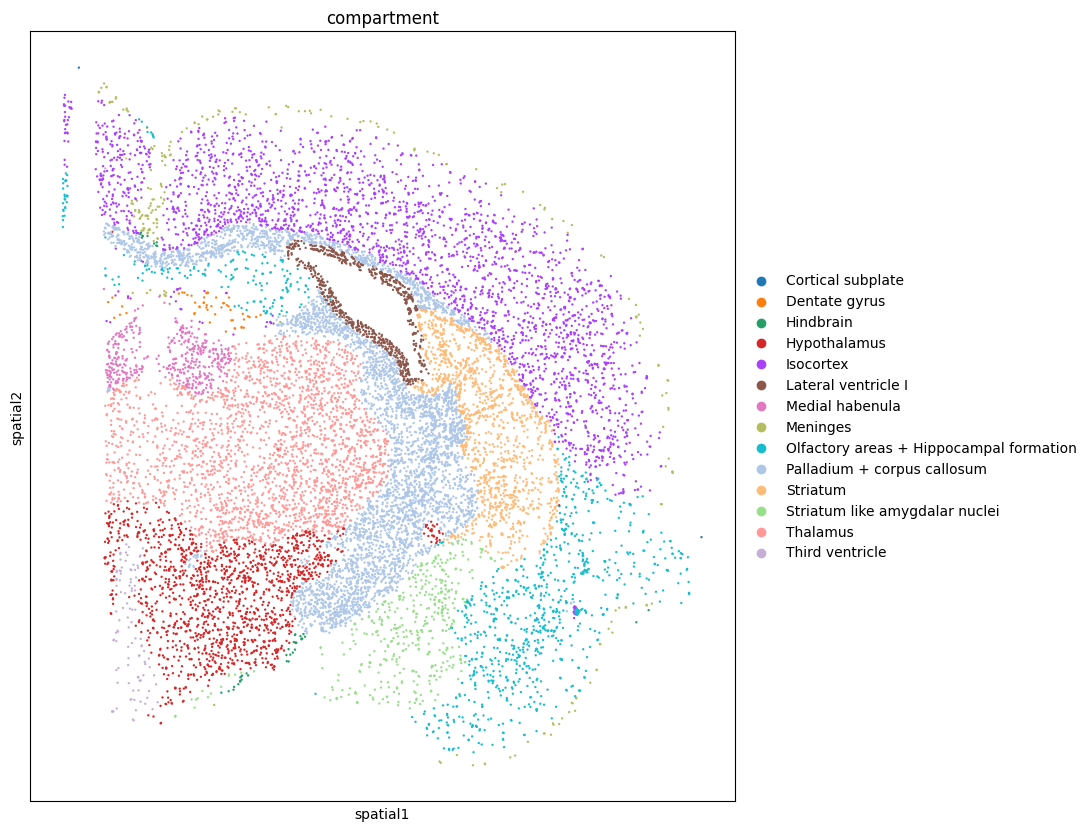

RB4350


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


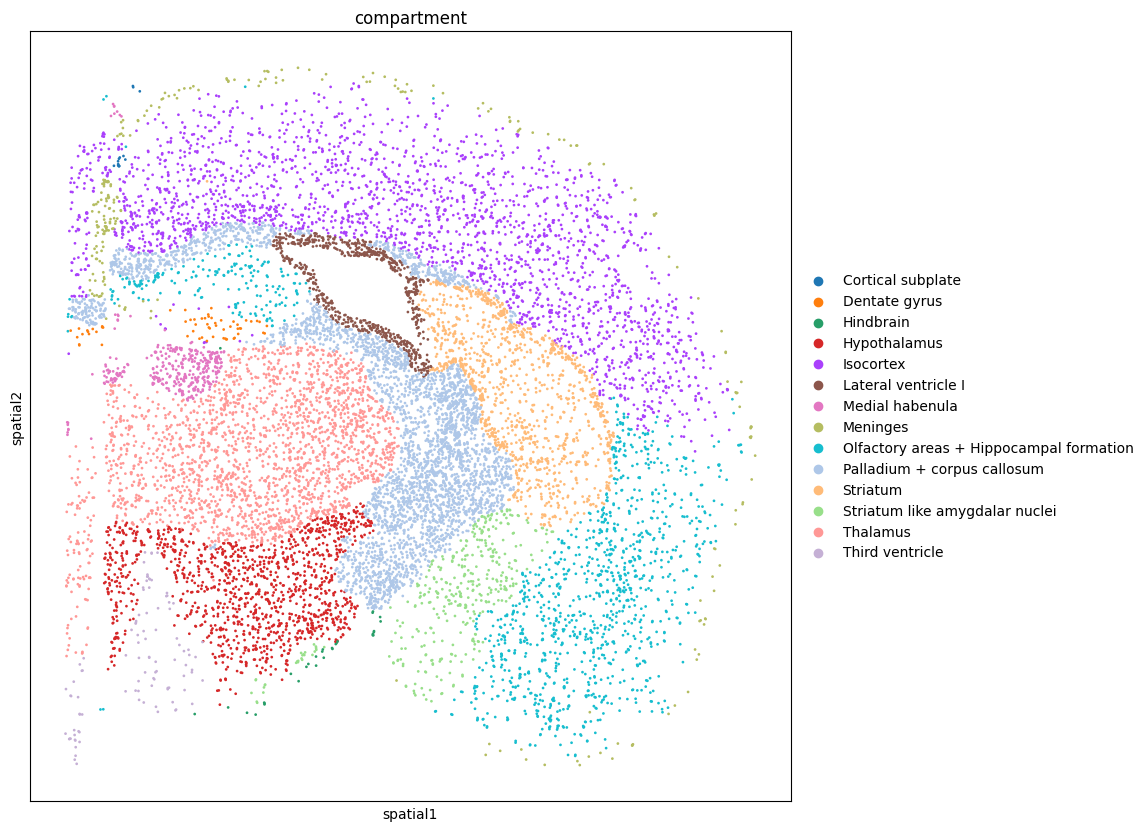

RB4401


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


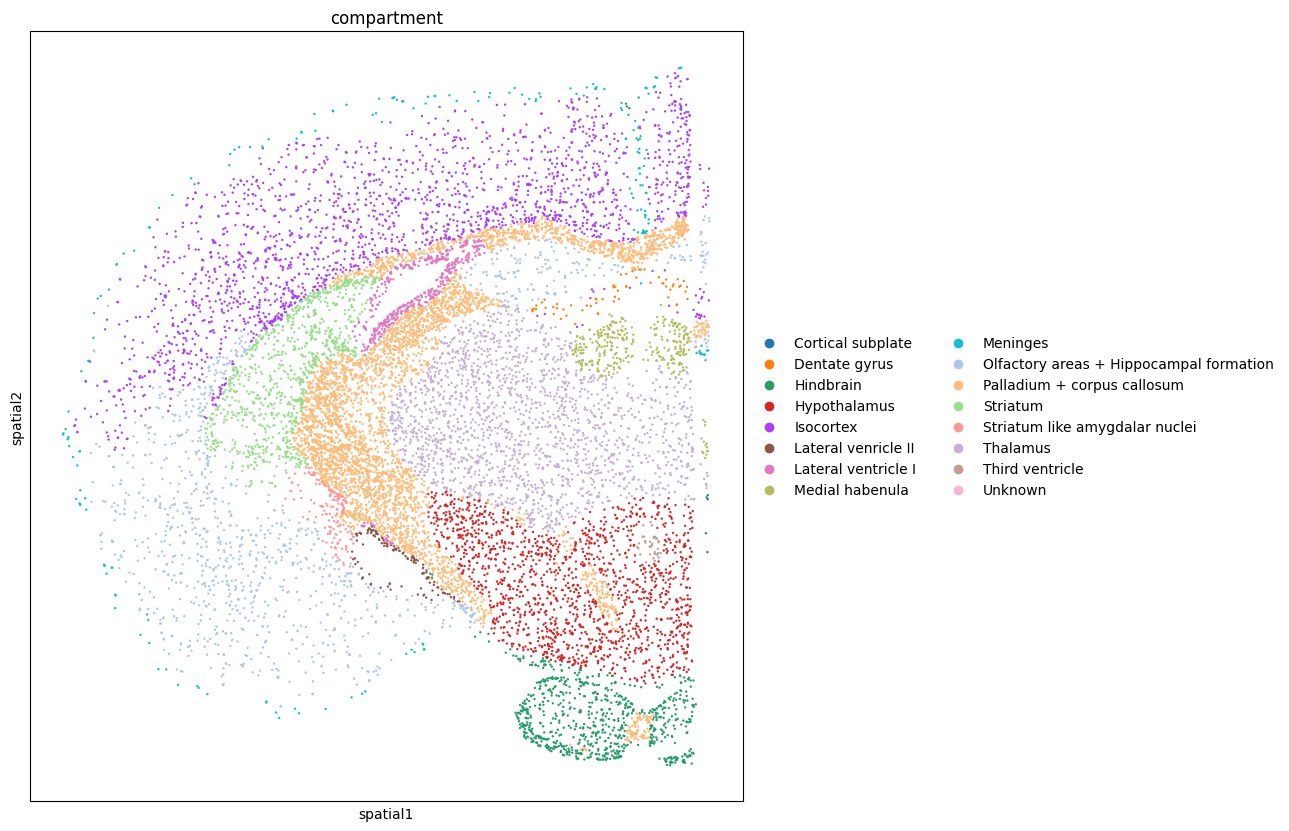

RB4403


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


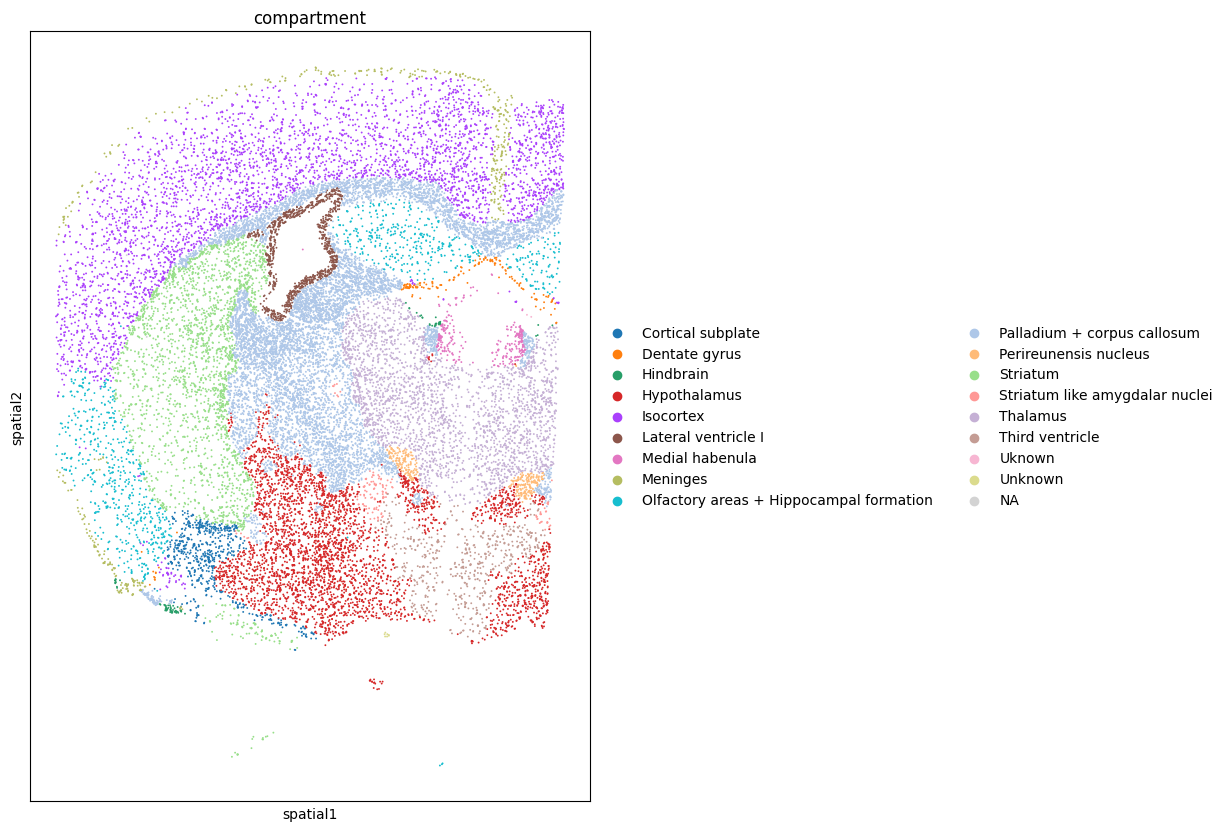

RB4405


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


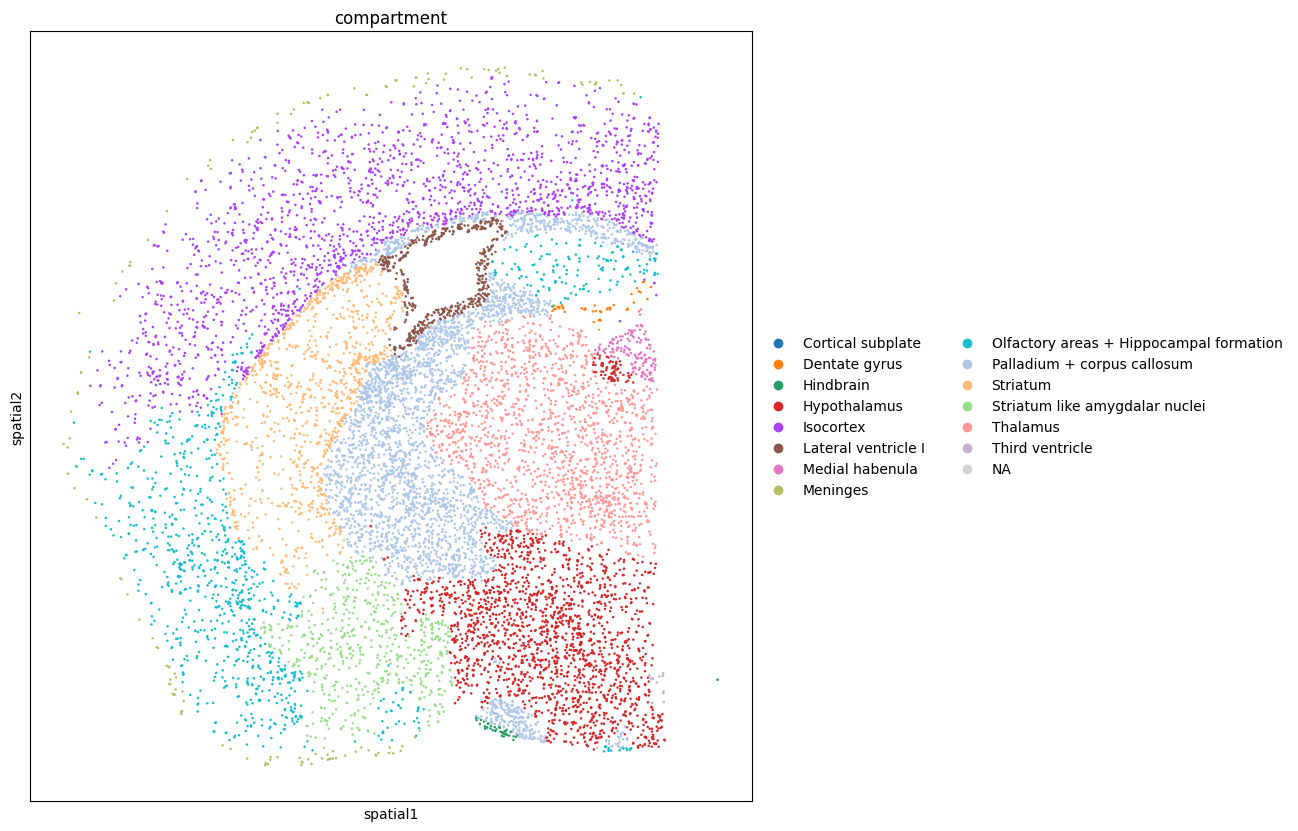

RB4498


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


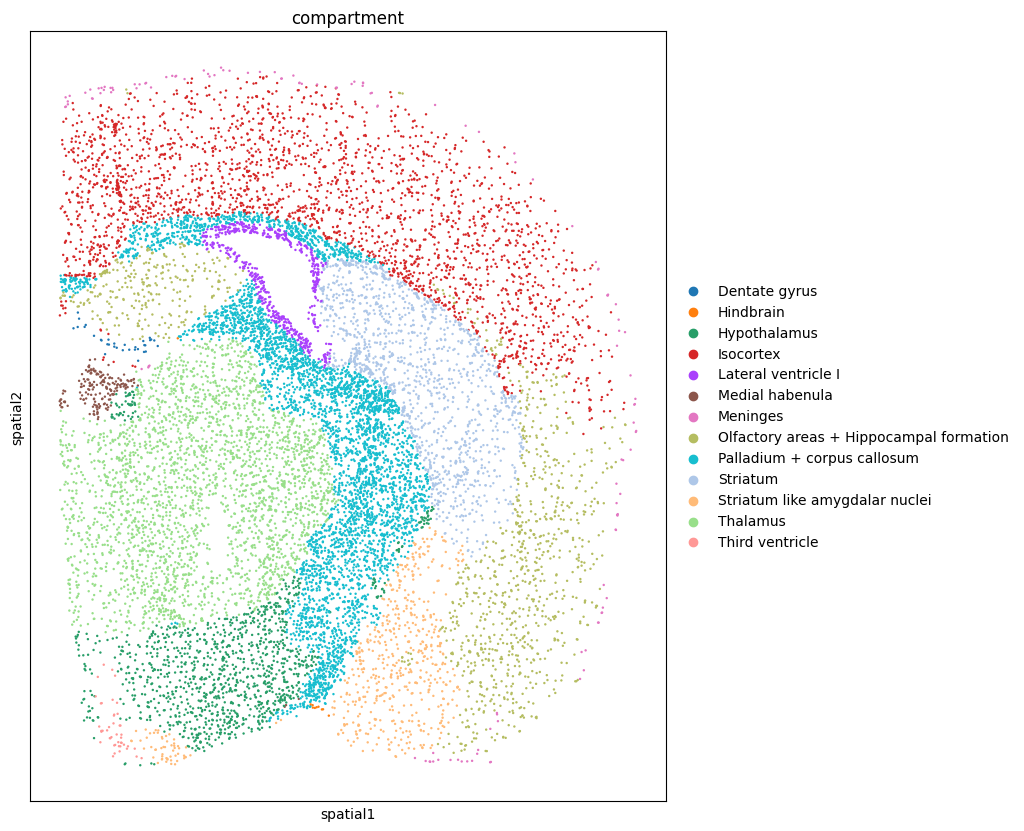

RB4620


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


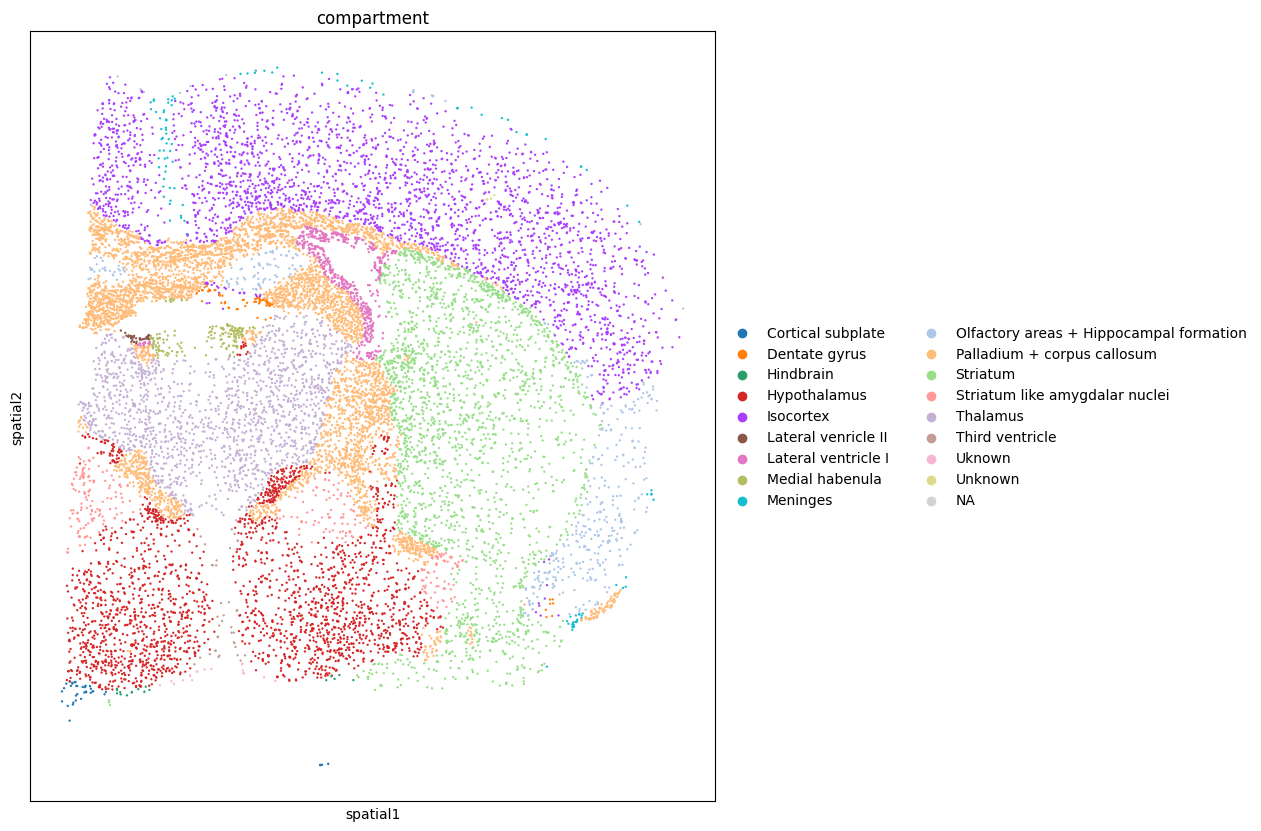

RB4627


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


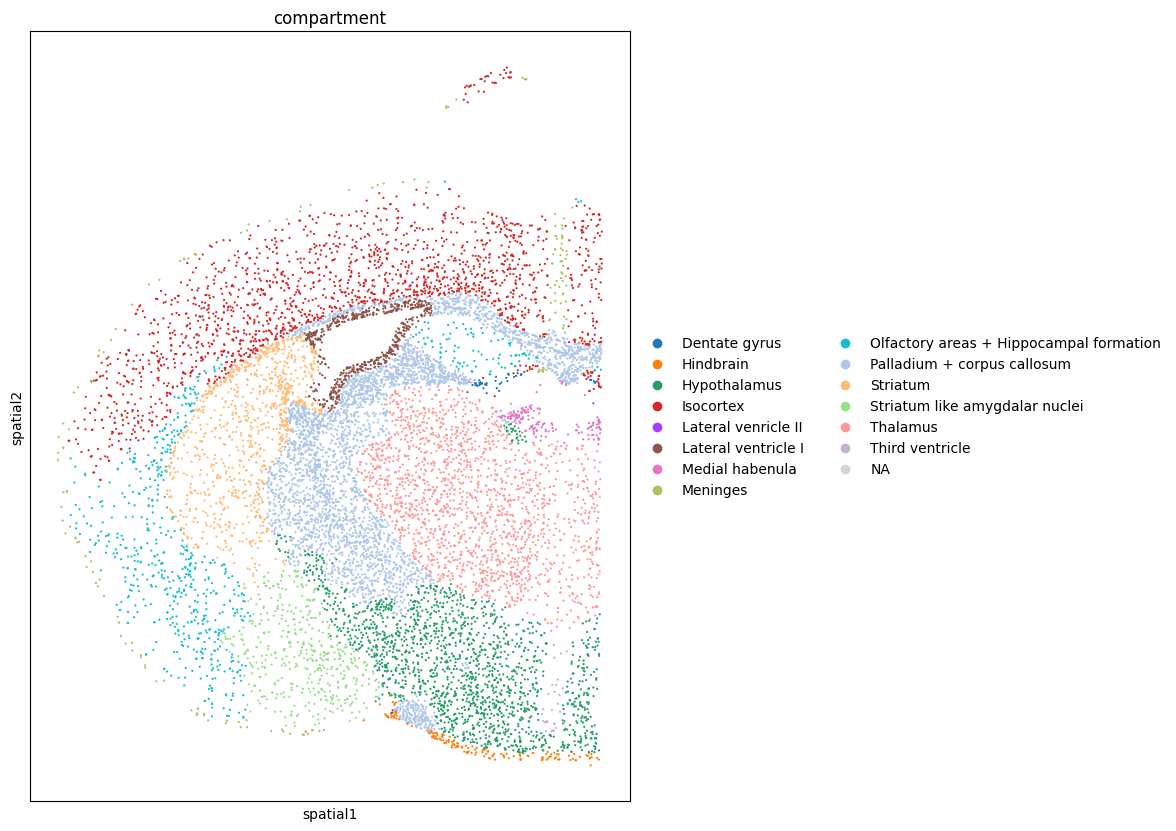

RB4630


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


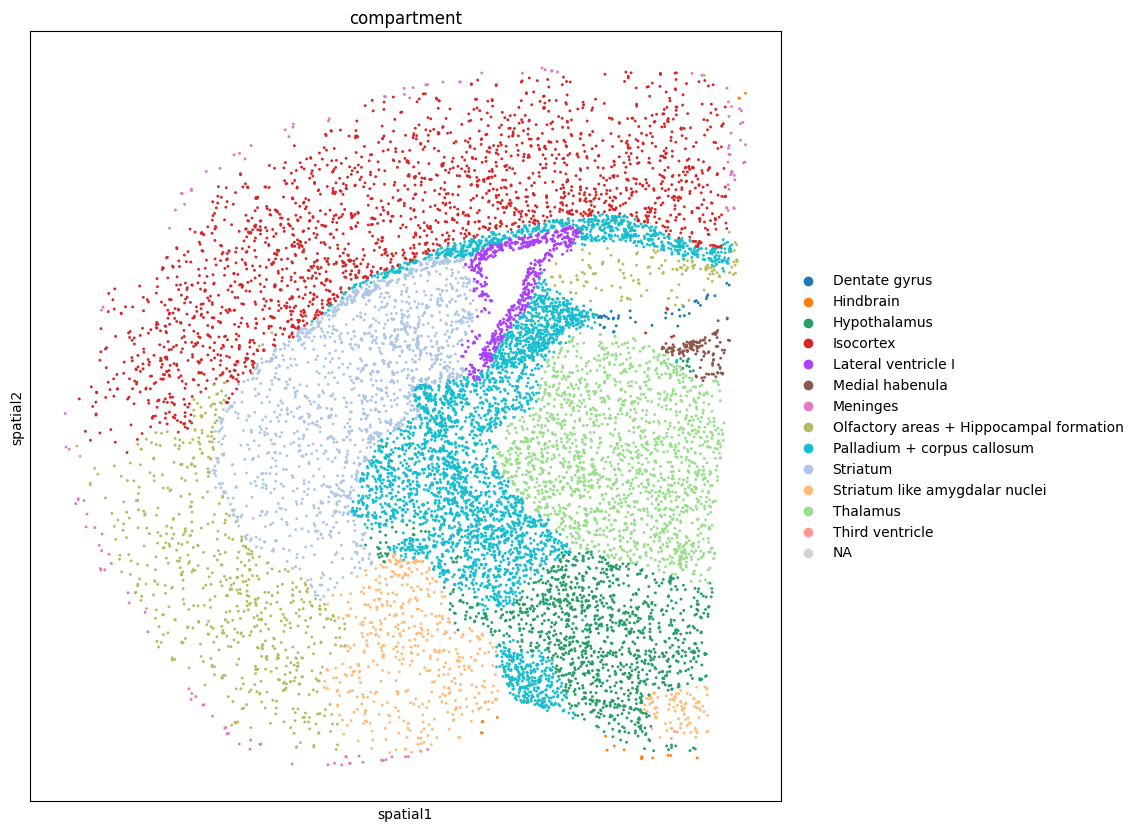

RB4653


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


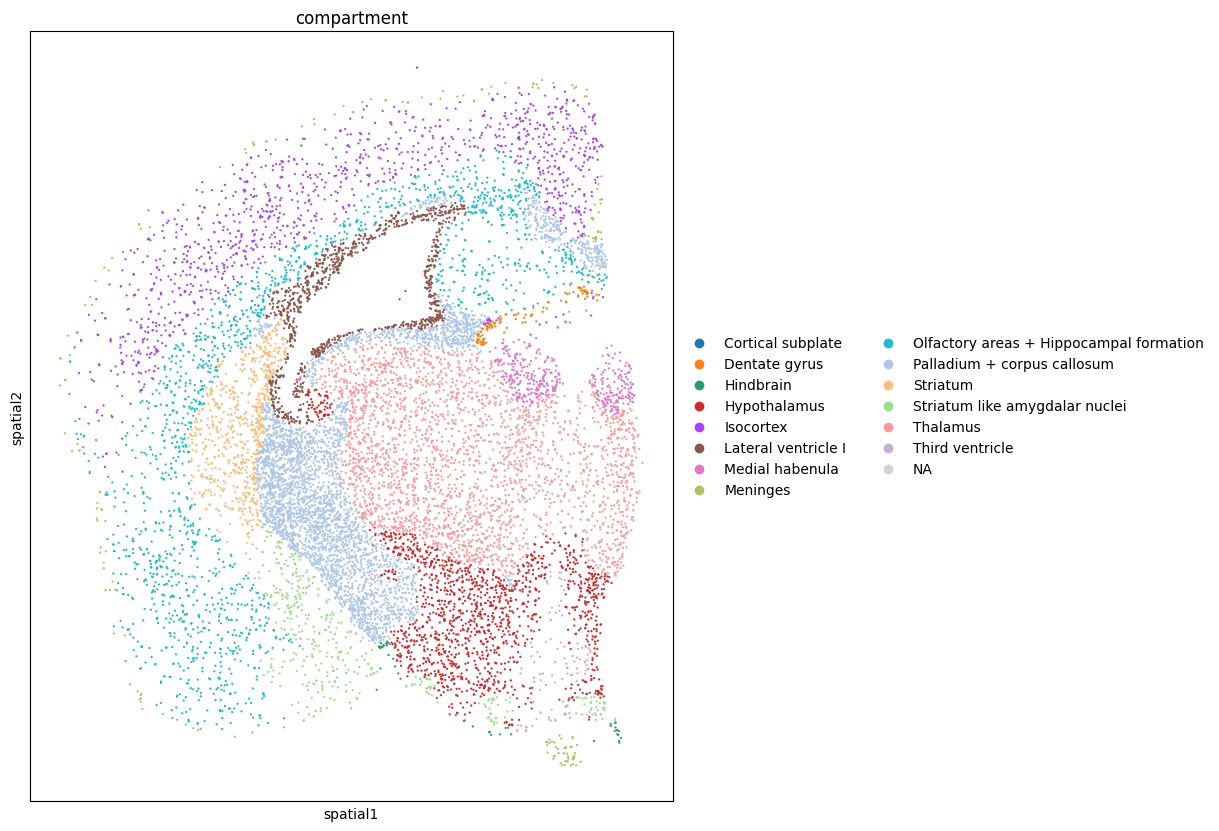

RB4658


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


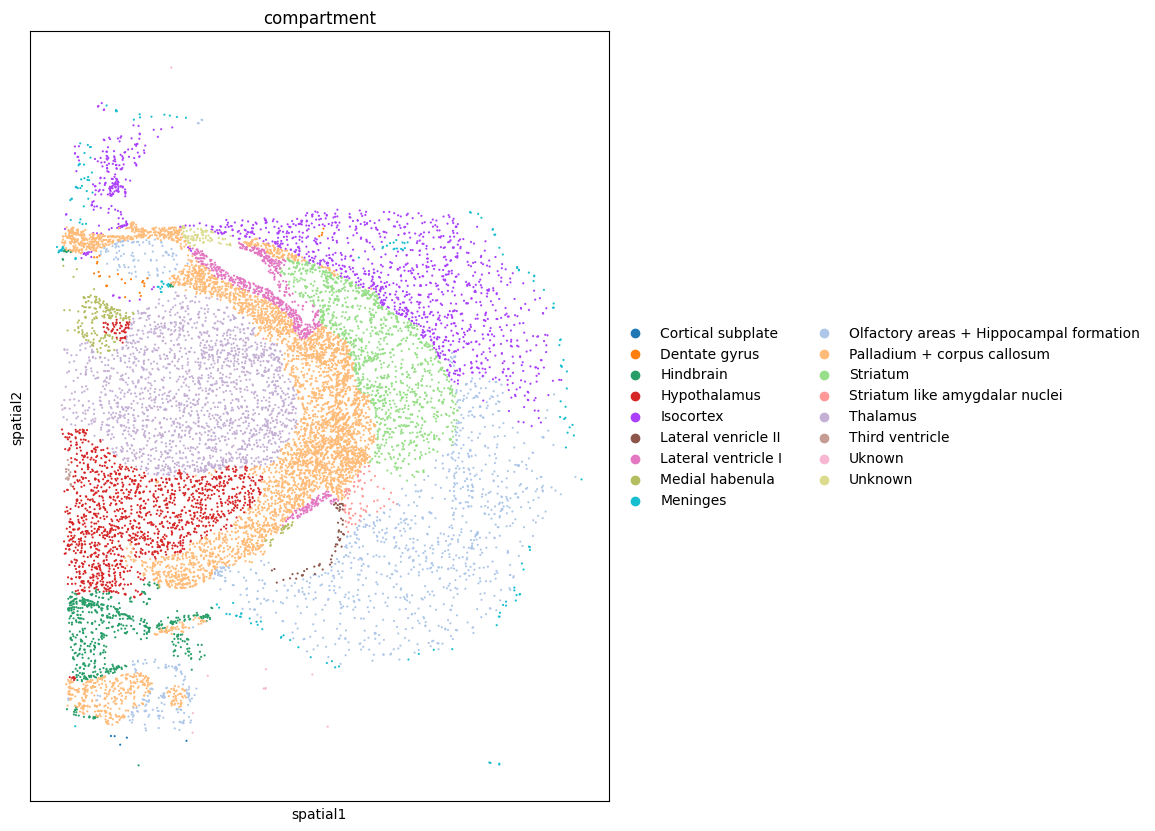

RB4676


/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


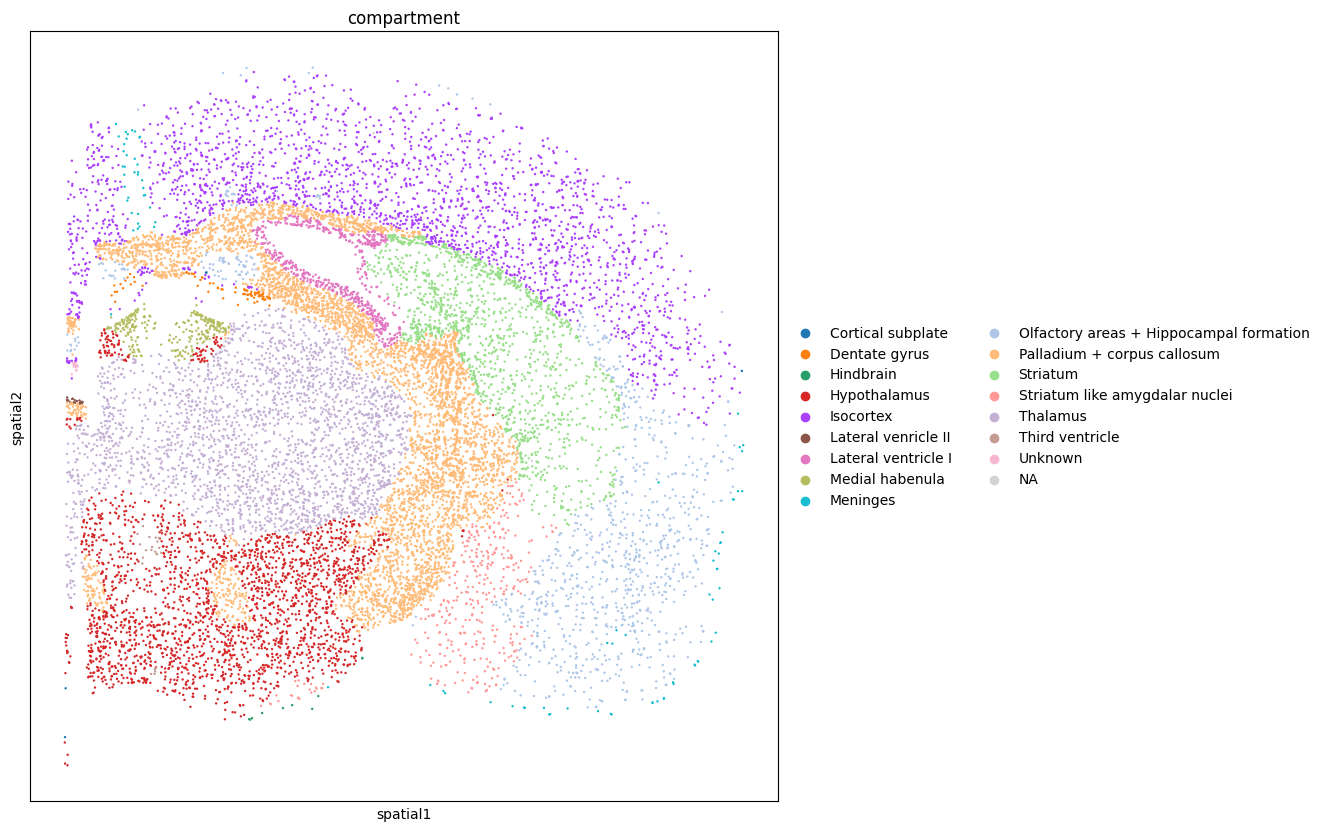

In [15]:
for run in adata.obs['sample_id'].unique():
    print(run)
    ad_int = adata[adata.obs['sample_id'] == run]

    with plt.rc_context({'figure.figsize': (20, 10)}):
        sc.pl.spatial(ad_int, spot_size=20, color = 'compartment')
    plt.show()
    

## Perform pseudobulk

In [16]:
pb = pseudobulk_by(
    adata,
    groupby=["cell_class", "region", "age", "condition", "sample_id"],  # 👈 add sample_id
    layer="counts" if "counts" in adata.layers else None,
    min_cells=30,
)

# Inspect one example
cell_type = "Mature oligodendrocytes"
region_age = list(pb[cell_type].keys())[0]
counts_df, meta_df = pb[cell_type][region_age]

print(region_age)
print("Counts shape:", counts_df.shape)
print(meta_df.head())

('Isocortex', '60')
Counts shape: (5101, 6)
                                                                 cell_class  \
pb_key                                                                        
Mature oligodendrocytes__Isocortex__60__control...  Mature oligodendrocytes   
Mature oligodendrocytes__Isocortex__60__control...  Mature oligodendrocytes   
Mature oligodendrocytes__Isocortex__60__mtDSB__...  Mature oligodendrocytes   
Mature oligodendrocytes__Isocortex__60__mtDSB__...  Mature oligodendrocytes   
Mature oligodendrocytes__Isocortex__60__mtDSB__...  Mature oligodendrocytes   

                                                       region age condition  \
pb_key                                                                        
Mature oligodendrocytes__Isocortex__60__control...  Isocortex  60   control   
Mature oligodendrocytes__Isocortex__60__control...  Isocortex  60   control   
Mature oligodendrocytes__Isocortex__60__mtDSB__...  Isocortex  60     mtDSB   
Mature 

In [17]:
pb_class = {}
for cl, regdict in pb.items():
    all_counts = []
    all_meta = []
    for (reg, age), (counts_df, meta_df) in regdict.items():
        all_counts.append(counts_df)
        all_meta.append(meta_df)
    counts_df_all = pd.concat(all_counts, axis=1)
    meta_df_all = pd.concat(all_meta)
    pb_class[cl] = (counts_df_all, meta_df_all)

In [18]:
counts_df, meta_df = pb_class["Mature oligodendrocytes"]
print("columns match index:", counts_df.columns.equals(meta_df.index))

columns match index: True


In [19]:
results_by_region = run_by_region(
    pb_class,
    condition_col="condition",
    age_col="age",
    region_col="region",
    ref_condition="control",
    min_per_condition=2,
    n_cpus=8,
    verbose=True
)

[Mature oligodendrocytes] skip Cortical subplate@21 (counts {'control': 3, 'mtDSB': 1})
[Mature oligodendrocytes] running Cortical subplate@60 ({'mtDSB': 3, 'control': 2})
Using None as control genes, passed at DeseqDataSet initialization


/var/folders/pm/2253tbm54v36j0l7lhshq73r0000gn/T/ipykernel_9565/519603999.py:405: DeprecationWarning: design_factors is deprecated and will soon be removed.Please consider providing a formulaic formula using the design argumentinstead.
  dds = DeseqDataSet(
Fitting size factors...
... done in 0.00 seconds.

/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: overflow encountered in matmul
  return X @ coef_.T + self.intercept_
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/sklearn/linear_model/_base.py:282: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_.T + self.intercept_
Fitting dispersions...
... done in 0.14 seconds.

Fitting dispersion trend curve...
/Users/christo

Log2 fold change & Wald test p-value: condition mtDSB vs control
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  0.421320       -1.831928  3.214944 -0.569816  0.568802   
9630013A20Rik  1.423291       -2.607439  3.040525 -0.857562  0.391134   
A1cf           0.000000             NaN       NaN       NaN       NaN   
A2m            0.167104       -0.498945  3.727452 -0.133857  0.893516   
Aatf           0.400279       -0.894795  2.532366 -0.353344  0.723831   
...                 ...             ...       ...       ...       ...   
Zswim9         0.175291       -0.450259  3.446156 -0.130656  0.896048   
Zup1           0.172562       -0.466974  3.504461 -0.133251  0.893995   
Zyx            2.750560       -0.863183  3.320989 -0.259917  0.794927   
Zzef1          0.070955       -0.983506  4.321723 -0.227573  0.819979   
a              0.001365       -1.734425  4.274867 -0.405726  0.684944   

                   padj  
2610035D17Rik  0.999839  
963001

Fitting dispersions...
... done in 0.11 seconds.

Fitting dispersion trend curve...
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: overflow encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: invalid value encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: overflow encountered in matmul


Log2 fold change & Wald test p-value: condition mtDSB vs control
                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik   2.723243        0.399970  1.208270  0.331027  0.740624   
9630013A20Rik  16.064564        2.756172  1.479527  1.862874  0.062480   
A1cf            0.000000             NaN       NaN       NaN       NaN   
A2m             2.326911        0.354908  1.297705  0.273489  0.784478   
Aatf            3.725675       -0.615293  0.991427 -0.620614  0.534854   
...                  ...             ...       ...       ...       ...   
Zswim9          1.126061       -0.816727  1.994770 -0.409434  0.682221   
Zup1            0.596411       -0.694510  2.419936 -0.286995  0.774116   
Zyx             3.142163        1.702087  1.220077  1.395065  0.162996   
Zzef1           2.446878        0.080439  1.214424  0.066237  0.947189   
a               0.000000             NaN       NaN       NaN       NaN   

                   padj  
2610035D17Rik  0.999

...

... done in 0.10 seconds.

Fitting dispersion trend curve...
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: overflow encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: invalid value encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: overflow encountered in matmul
  mu = covariates_fit @

Log2 fold change & Wald test p-value: condition mtDSB vs control
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  1.330567        1.130065  1.810910  0.624031  0.532607   
9630013A20Rik  0.210507        1.448254  2.506923  0.577702  0.563465   
A1cf           0.000000             NaN       NaN       NaN       NaN   
A2m            0.171547        1.171804  2.536958  0.461893  0.644158   
Aatf           1.789063       -1.492827  1.587720 -0.940233  0.347098   
...                 ...             ...       ...       ...       ...   
Zswim9         0.296978        0.794313  2.075410  0.382726  0.701923   
Zup1           0.472974       -0.363275  2.554294 -0.142221  0.886905   
Zyx            1.764080        0.289058  1.643127  0.175920  0.860357   
Zzef1          2.861853        1.363241  1.344935  1.013612  0.310768   
a              0.000000             NaN       NaN       NaN       NaN   

                   padj  
2610035D17Rik  0.999499  
963001

Fitting dispersions...
... done in 0.12 seconds.

Fitting dispersion trend curve...
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: overflow encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:209: RuntimeWarning: invalid value encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: divide by zero encountered in matmul
  mu = covariates_fit @ coeffs
/Users/christoffer/miniconda3/envs/sc_py312/lib/python3.12/site-packages/pydeseq2/default_inference.py:213: RuntimeWarning: overflow encountered in matmul


Log2 fold change & Wald test p-value: condition mtDSB vs control
               baseMean  log2FoldChange     lfcSE      stat    pvalue  \
2610035D17Rik  2.908388       -0.558981  1.333841 -0.419076  0.675161   
9630013A20Rik  0.845762       -1.291952  1.487966 -0.868267  0.385248   
A1cf           0.000000             NaN       NaN       NaN       NaN   
A2m            0.206526        1.638194  2.056801  0.796476  0.425755   
Aatf           2.058825       -0.552328  1.398137 -0.395045  0.692809   
...                 ...             ...       ...       ...       ...   
Zswim9         0.502411        0.720759  1.726832  0.417388  0.676395   
Zup1           0.668407       -0.731186  1.512052 -0.483572  0.628690   
Zyx            2.352695       -0.596683  1.292590 -0.461618  0.644355   
Zzef1          5.007209        0.956470  1.163927  0.821762  0.411213   
a              0.000000             NaN       NaN       NaN       NaN   

                   padj  
2610035D17Rik  0.999229  
963001

... done in 0.10 seconds.



In [20]:
results_by_region

{'Mature oligodendrocytes': {'Cortical subplate': {'simple_effects': {'60':                baseMean  log2FoldChange     lfcSE      stat    pvalue  \
    2610035D17Rik  0.421320       -1.831928  3.214944 -0.569816  0.568802   
    9630013A20Rik  1.423291       -2.607439  3.040525 -0.857562  0.391134   
    A1cf           0.000000             NaN       NaN       NaN       NaN   
    A2m            0.167104       -0.498945  3.727452 -0.133857  0.893516   
    Aatf           0.400279       -0.894795  2.532366 -0.353344  0.723831   
    ...                 ...             ...       ...       ...       ...   
    Zswim9         0.175291       -0.450259  3.446156 -0.130656  0.896048   
    Zup1           0.172562       -0.466974  3.504461 -0.133251  0.893995   
    Zyx            2.750560       -0.863183  3.320989 -0.259917  0.794927   
    Zzef1          0.070955       -0.983506  4.321723 -0.227573  0.819979   
    a              0.001365       -1.734425  4.274867 -0.405726  0.684944   
    

In [21]:
def summarize_region_impact(results_by_region, cell_class, metric="sum_neglog10q", age=None):
    rows = []
    for reg, d in results_by_region[cell_class].items():
        imp = d["impact"]
        if age is None:
            vals = [v[metric] for v in imp.values() if v]
            score = np.nansum(vals)
        else:
            score = imp.get(str(age), {}).get(metric, 0.0)
        rows.append({"region": reg, "score": score})
    return pd.DataFrame(rows).sort_values("score", ascending=False).reset_index(drop=True)

rank_regions = summarize_region_impact(results_by_region, "Mature oligodendrocytes")
print(rank_regions.head(10))

                        region      score
0                 Hypothalamus  92.886849
1                     Thalamus  34.812953
2  Palladium + corpus callosum   8.007658
3          Lateral ventricle I   2.935740
4              Olfactory areas   1.887628
5              Medial habenula   1.677529
6                     Striatum   1.589046
7            Cortical subplate   0.000000
8        Perireunensis nucleus   0.000000
9              Third ventricle   0.000000


0                   Hypothalamus
1                       Thalamus
2    Palladium + corpus callosum
3            Lateral ventricle I
4                Olfactory areas
5                Medial habenula
6                       Striatum
7              Cortical subplate
8          Perireunensis nucleus
9                Third ventricle
Name: region, dtype: object

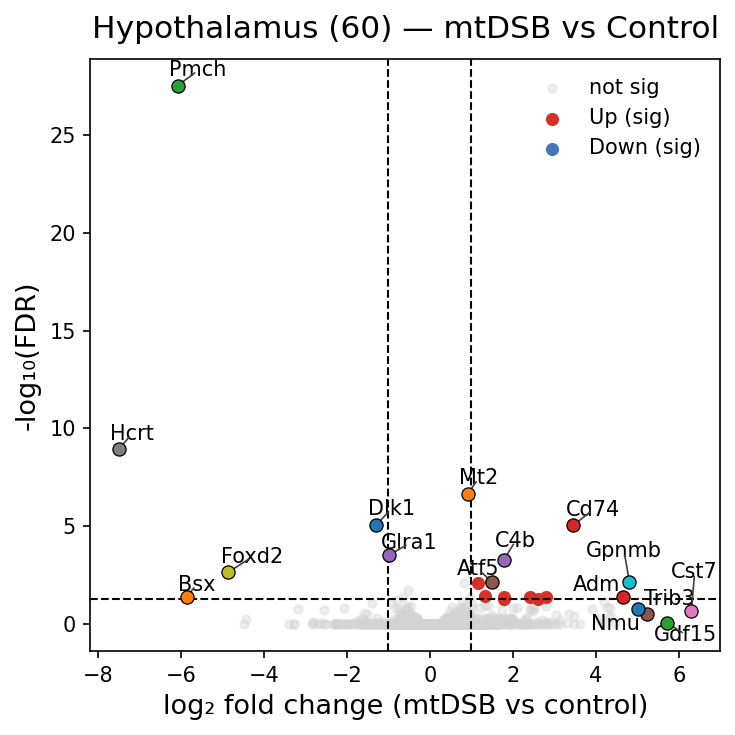

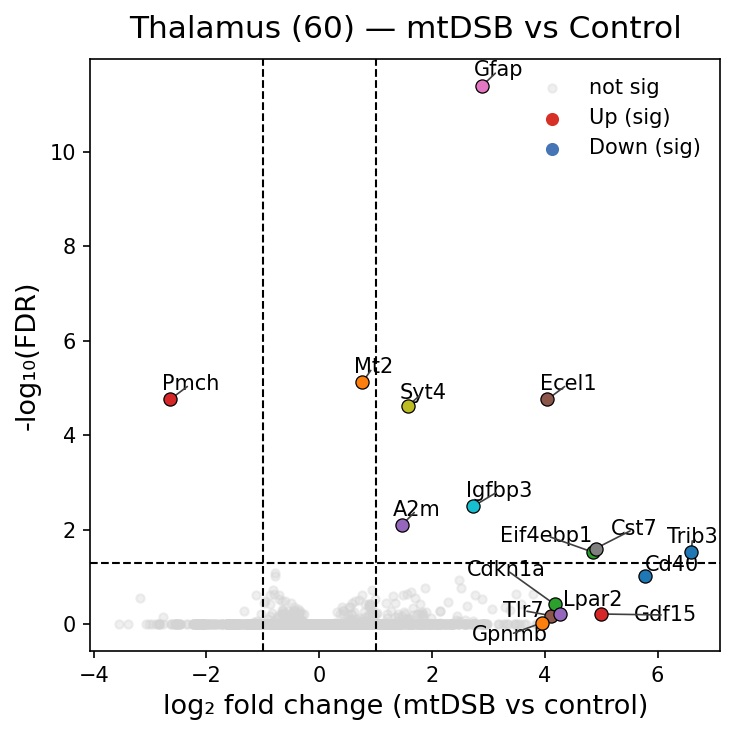

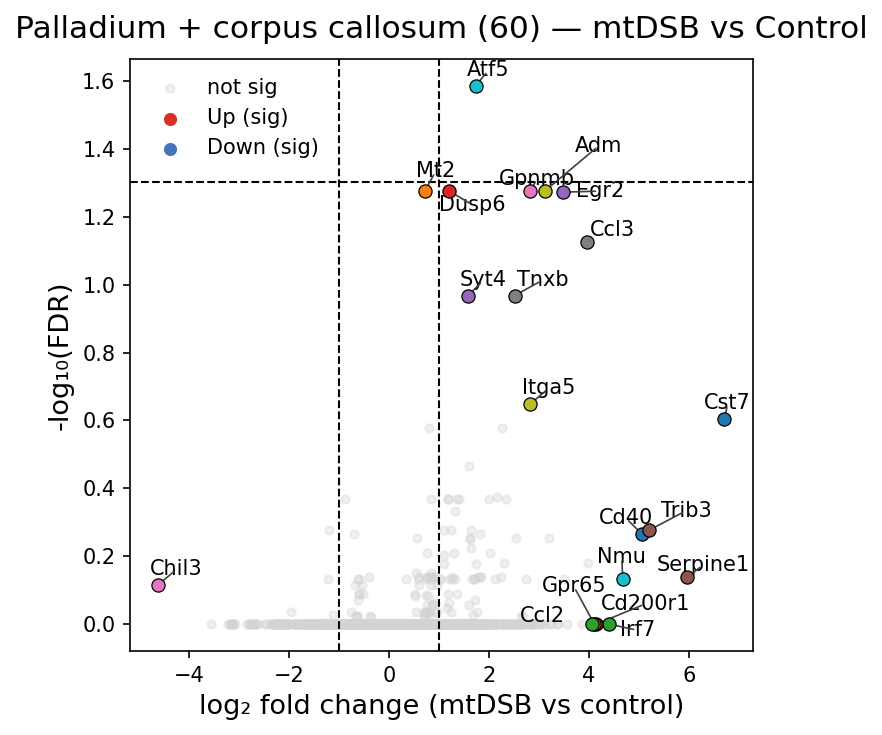

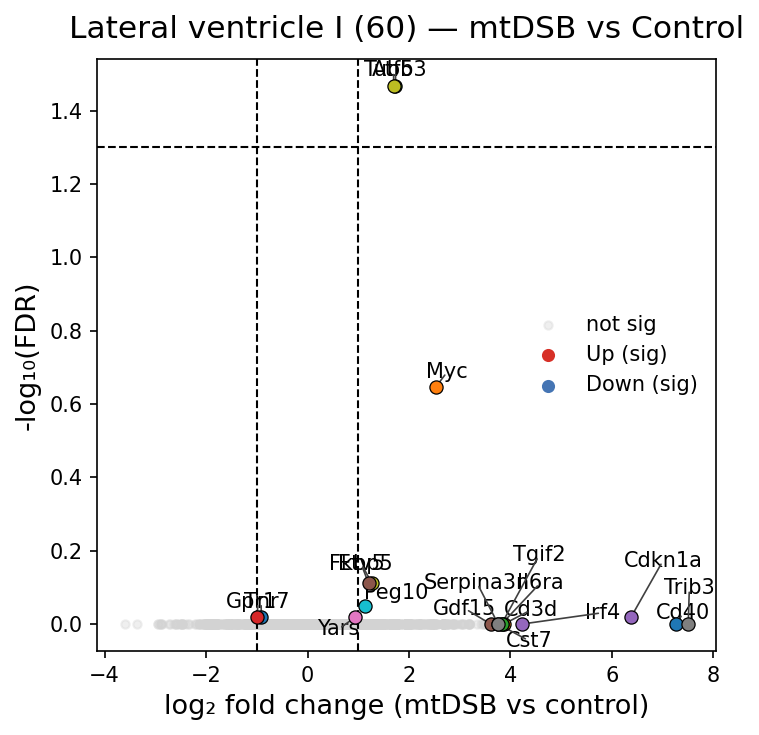

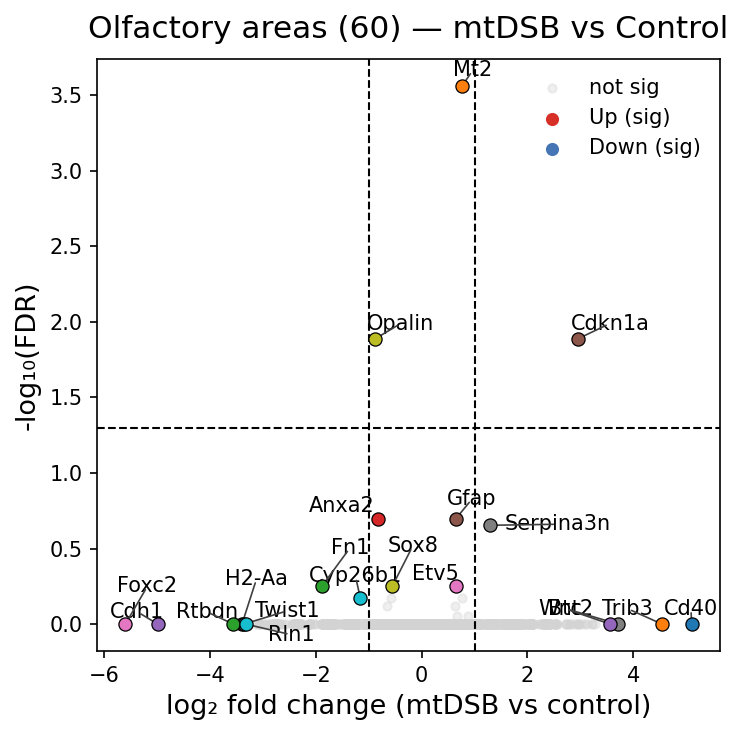

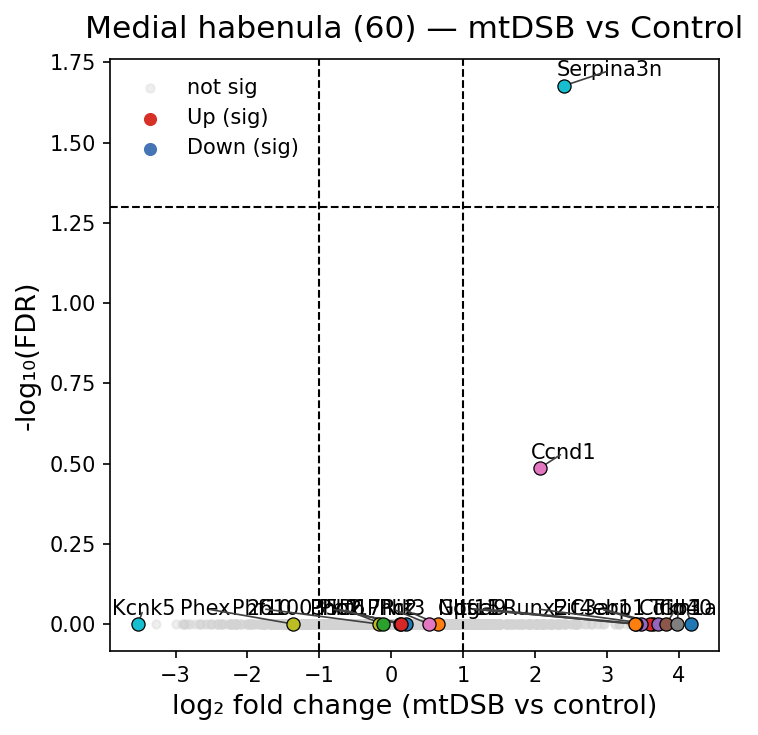

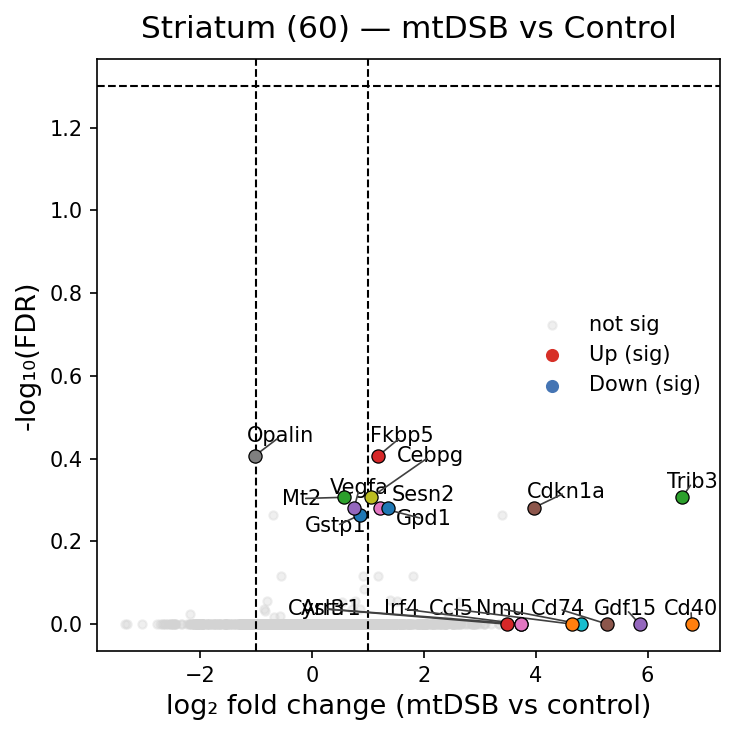

14 [0.39095042 0.81176407]
17 [ 0.43893373 -0.60841187]


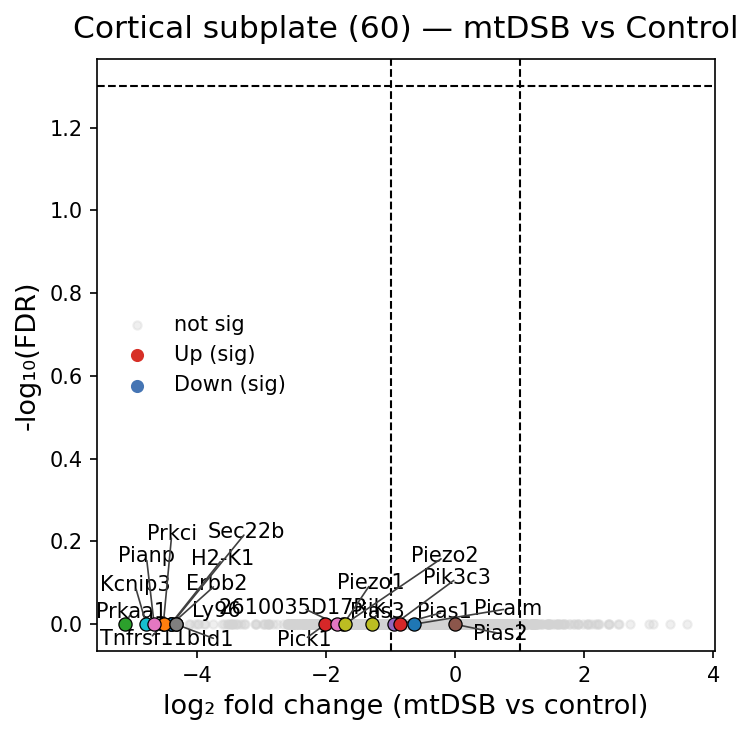

KeyError: '60'

In [29]:
for region in rank_regions.head(10).region:
    res_hypo_60 = results_by_region["Mature oligodendrocytes"][region]["simple_effects"]["60"]
    volcano_clean(res_hypo_60, title=region + " (60) — mtDSB vs Control", figsize=(5, 5))

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


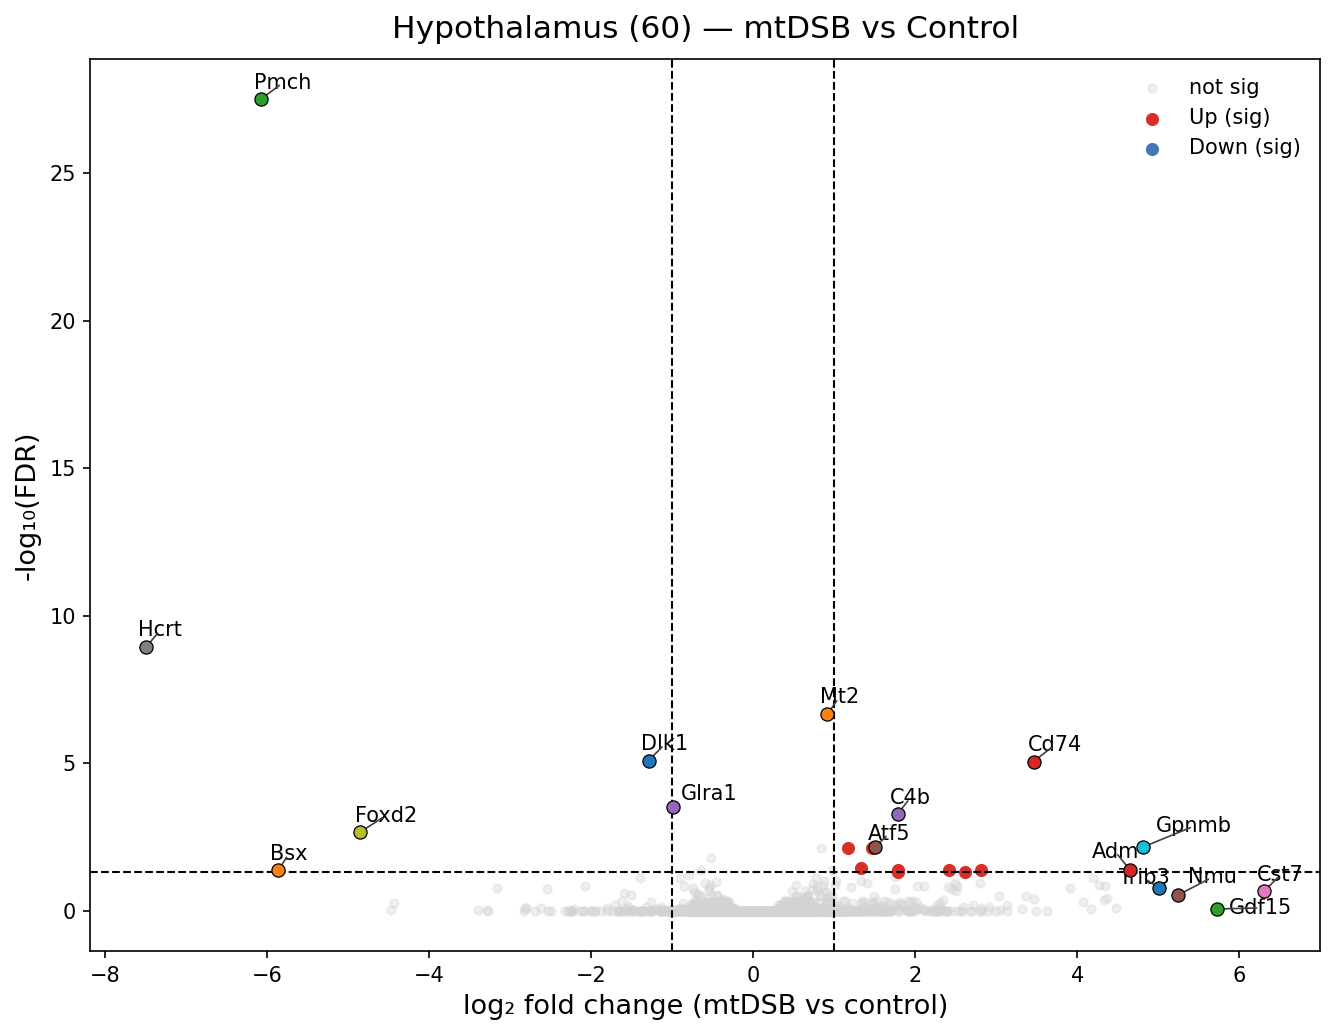

In [22]:
res_hypo_60 = results_by_region["Mature oligodendrocytes"]["Hypothalamus"]["simple_effects"]["60"]
volcano_clean(res_hypo_60, title="Hypothalamus (60) — mtDSB vs Control")

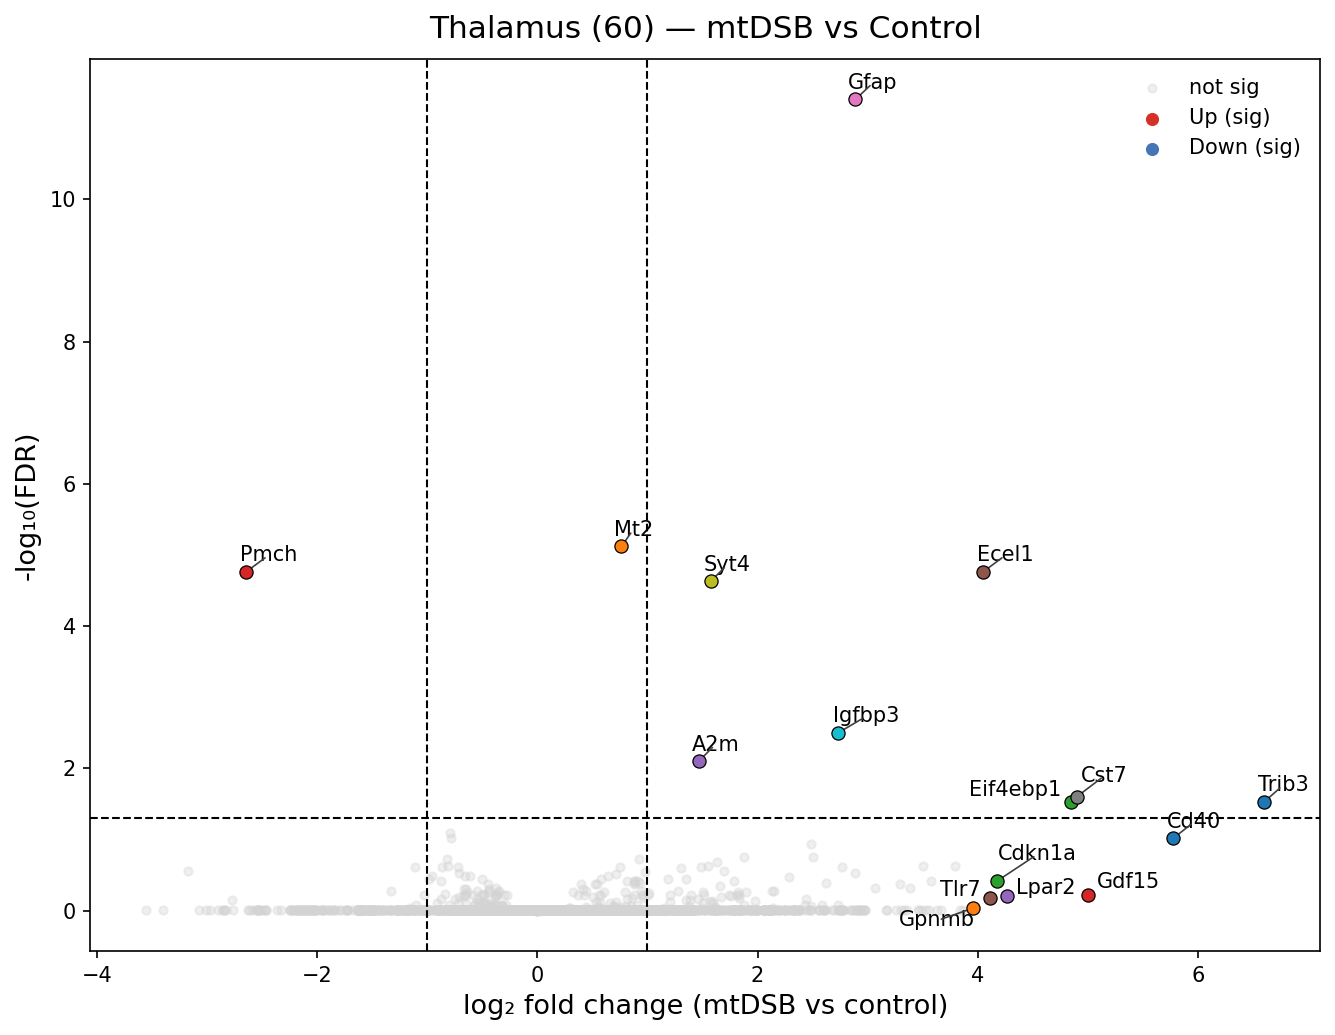

In [23]:
res_hypo_60 = results_by_region["Mature oligodendrocytes"]["Thalamus"]["simple_effects"]["60"]
volcano_clean(res_hypo_60, title="Thalamus (60) — mtDSB vs Control")

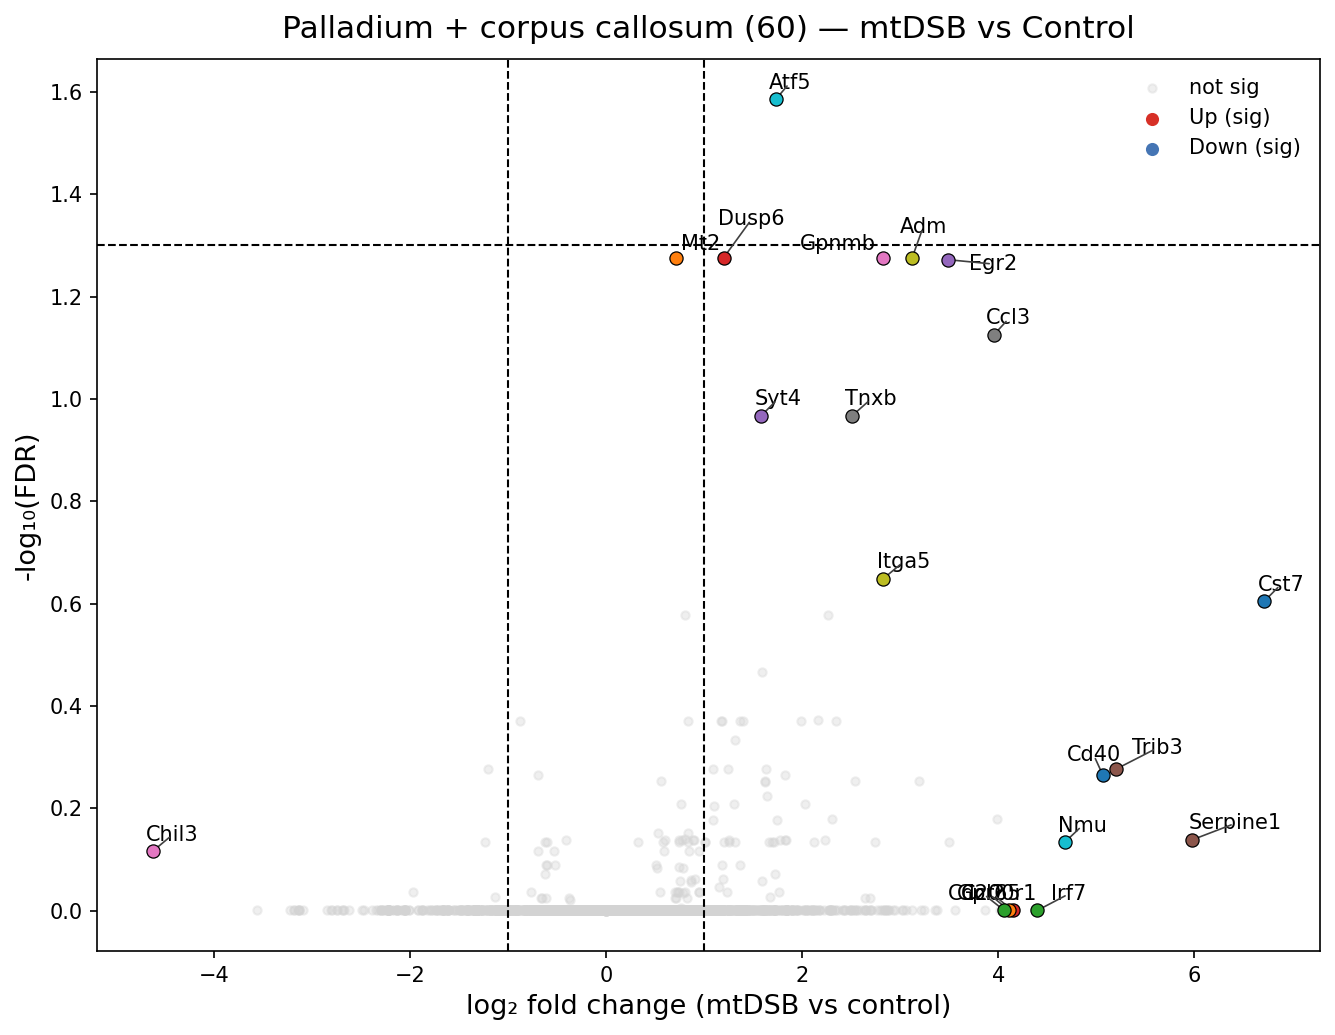

In [24]:
res_hypo_60 = results_by_region["Mature oligodendrocytes"]["Palladium + corpus callosum"]["simple_effects"]["60"]
volcano_clean(res_hypo_60, title="Palladium + corpus callosum (60) — mtDSB vs Control")

In [94]:
top_regions = rank_regions.head(5)["region"].tolist()
print("Top affected regions:", top_regions)

Top affected regions: ['Hypothalamus', 'Thalamus', 'Palladium + corpus callosum', 'Lateral ventricle I', 'Olfactory areas']


In [95]:
import numpy as np
import pandas as pd

def extract_top_genes(
    results_by_region,
    cell_class,
    regions=None,
    ages=None,
    padj_thr=0.05,
    lfc_thr=1.0,
    top_n=50
):
    rows = []
    res_cl = results_by_region[cell_class]
    if regions is None:
        regions = list(res_cl.keys())

    for reg in regions:
        reg_data = res_cl.get(reg, {})
        effects = reg_data.get("simple_effects", {})
        if not effects:
            continue

        # normalize available age keys to strings
        avail_age_keys = {str(k): k for k in effects.keys()}
        ages_to_use = [str(a) for a in (ages if ages is not None else effects.keys())]

        for age_str in ages_to_use:
            key = avail_age_keys.get(age_str, None)
            if key is None:
                continue
            res = effects.get(key, None)
            if res is None or res.empty:
                continue

            # standard DESeq2/PyDESeq2 columns
            if ("padj" not in res.columns) or ("log2FoldChange" not in res.columns):
                # skip if table doesn't look like a DE result
                continue

            sig = res[(res["padj"] < padj_thr) & (res["log2FoldChange"].abs() >= lfc_thr)].copy()
            if sig.empty:
                continue

            sig["region"] = reg
            sig["age"] = age_str
            sig["neglog10FDR"] = -np.log10(sig["padj"].clip(lower=1e-300))
            sig.rename(columns={"log2FoldChange": "log2FC"}, inplace=True)

            rows.append(sig[["log2FC", "padj", "neglog10FDR", "region", "age"]])

    if not rows:
        print("No genes passed the thresholds; try relaxing padj_thr or lfc_thr.")
        return pd.DataFrame()

    df = pd.concat(rows).sort_values("neglog10FDR", ascending=False)
    return df.head(top_n)

In [105]:
top_regions = rank_regions.head(20)["region"].tolist()
top_genes = extract_top_genes(results_by_region, "Mature oligodendrocytes", regions=top_regions)
top_genes.head(20)
top_genes = top_genes.reset_index()

In [106]:
top_regions

['Hypothalamus',
 'Thalamus',
 'Palladium + corpus callosum',
 'Lateral ventricle I',
 'Olfactory areas',
 'Medial habenula',
 'Striatum',
 'Cortical subplate',
 'Perireunensis nucleus',
 'Third ventricle',
 'Striatum like amygdalar nuclei',
 'Meninges',
 'Dentate gyrus',
 'Lateral venricle II',
 'Isocortex',
 'Hindbrain',
 'Unknown']

In [107]:
top_genes

,index,log2FC,padj,neglog10FDR,region,age
0,Pmch,-6.081558,3.147373e-28,27.502052,Hypothalamus,60
1,Gfap,2.888829,3.936182e-12,11.404925,Thalamus,60
2,Hcrt,-7.490894,1.133622e-09,8.945532,Hypothalamus,60
3,Sst,1.894666,2.333254e-07,6.632038,Hypothalamus,21
4,Dlk1,-1.291782,8.202660e-06,5.086045,Hypothalamus,60
5,Cd74,3.459638,8.866540e-06,5.052246,Hypothalamus,60
6,Ecel1,4.047177,1.733423e-05,4.761096,Thalamus,60
7,Pmch,-2.644837,1.733423e-05,4.761096,Thalamus,60
8,Syt4,1.575409,2.344469e-05,4.629955,Thalamus,60
9,Fezf1,3.958923,9.654090e-05,4.015289,Hypothalamus,21


In [108]:
summary = (
    top_genes.groupby('index')
    .agg(
        n_regions=("region", "nunique"),
        mean_LFC=("log2FC", "mean"),
        mean_neglog10FDR=("neglog10FDR", "mean"),
    )
    .sort_values("n_regions", ascending=False)
)
print(summary.head(20))

               n_regions  mean_LFC  mean_neglog10FDR
index                                               
Atf5                   3  1.644258          1.736224
Gfap                   2  2.273194          4.993807
Pmch                   2 -4.363197         16.131574
Ecel1                  2  2.843040          3.576187
Nr4a2                  1 -3.376334          1.379443
Igfbp3                 1  2.731325          2.498147
Msn                    1  1.470267          2.131397
Mt1                    1  1.256062          2.437742
Myc                    1  1.791258          1.363045
Nptx2                  1  1.910976          1.379443
Pdyn                   1  2.434531          3.962556
Otp                    1  2.694992          1.379443
Hcrt                   1 -7.490894          8.945532
Serpina3n              1  2.404018          1.677529
Slc18a3                1  2.899519          1.593149
Sst                    1  1.894666          6.632038
Syt4                   1  1.575409          4.

In [109]:
import pandas as pd
import numpy as np

# your summary df is called `summary` (index=gene; cols: n_regions, mean_LFC, mean_neglog10FDR)
summary = summary.rename(columns={
    summary.columns[0]: "n_regions",
    summary.columns[1]: "mean_LFC",
    summary.columns[2]: "mean_neglog10FDR"
})

# objective panels
core_up   = summary.query("n_regions >= 2 & mean_LFC > 0 & mean_neglog10FDR >= 2").index.tolist()
core_down = summary.query("n_regions >= 2 & mean_LFC < 0 & mean_neglog10FDR >= 2").index.tolist()

# add high-effect one-offs to ensure biology is covered
hi_effect = summary.loc[summary["mean_neglog10FDR"].rank(ascending=False) <= 10].index.tolist()

gene_panel = sorted(set(core_up + core_down + hi_effect))
print("Gene panel:", gene_panel)

Gene panel: ['Cd74', 'Dlk1', 'Ecel1', 'Fezf1', 'Gfap', 'Hcrt', 'Pdyn', 'Pmch', 'Sst', 'Syt4']


In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def region_gene_matrix(results_by_region, cell_class, genes, ages=None, padj_thr=0.05):
    """
    Build region×gene matrix of log2FC for a given cell_class.
    Rows = "region @ age", Cols = genes.
    Non-significant entries (padj >= padj_thr) are set to NaN.
    """
    rows = []
    res_cl = results_by_region[cell_class]

    for reg, block in res_cl.items():
        se = block.get("simple_effects", {})
        if not se:
            continue

        # Map available age keys to strings so we can match robustly
        age_key_map = {str(k): k for k in se.keys()}
        ages_iter = [str(a) for a in (ages if ages is not None else se.keys())]

        for age_str in ages_iter:
            key = age_key_map.get(age_str)
            if key is None:
                continue
            res = se.get(key)
            if res is None or res.empty:
                continue
            # keep only requested genes that exist
            present = res.index.intersection(genes)
            if len(present) == 0:
                continue

            # standard DESeq2 columns: log2FoldChange, padj
            sub = res.loc[present, ["log2FoldChange", "padj"]].copy()
            # mask non-significant to NaN
            sub.loc[sub["padj"] >= padj_thr, "log2FoldChange"] = np.nan

            row = sub["log2FoldChange"]
            row.name = f"{reg} @ {age_str}"
            rows.append(row)

    if not rows:
        return pd.DataFrame(columns=genes)

    mat = pd.DataFrame(rows).reindex(columns=genes)
    return mat

def heatmap(mat, title):
    if mat.empty:
        print("No data to plot for:", title)
        return
    arr = mat.values.astype(float)
    vmax = np.nanmax(np.abs(arr))
    vmax = 1.0 if not np.isfinite(vmax) or vmax == 0 else vmax
    plt.figure(figsize=(0.5*mat.shape[1]+4, 0.4*mat.shape[0]+3), dpi=150)
    im = plt.imshow(arr, aspect="auto", vmin=-vmax, vmax=+vmax)
    plt.colorbar(im, label="log2FC (mtDSB vs control)")
    plt.yticks(range(mat.shape[0]), mat.index)
    plt.xticks(range(mat.shape[1]), mat.columns, rotation=60, ha="right")
    plt.title(title)
    plt.tight_layout()
    plt.show()

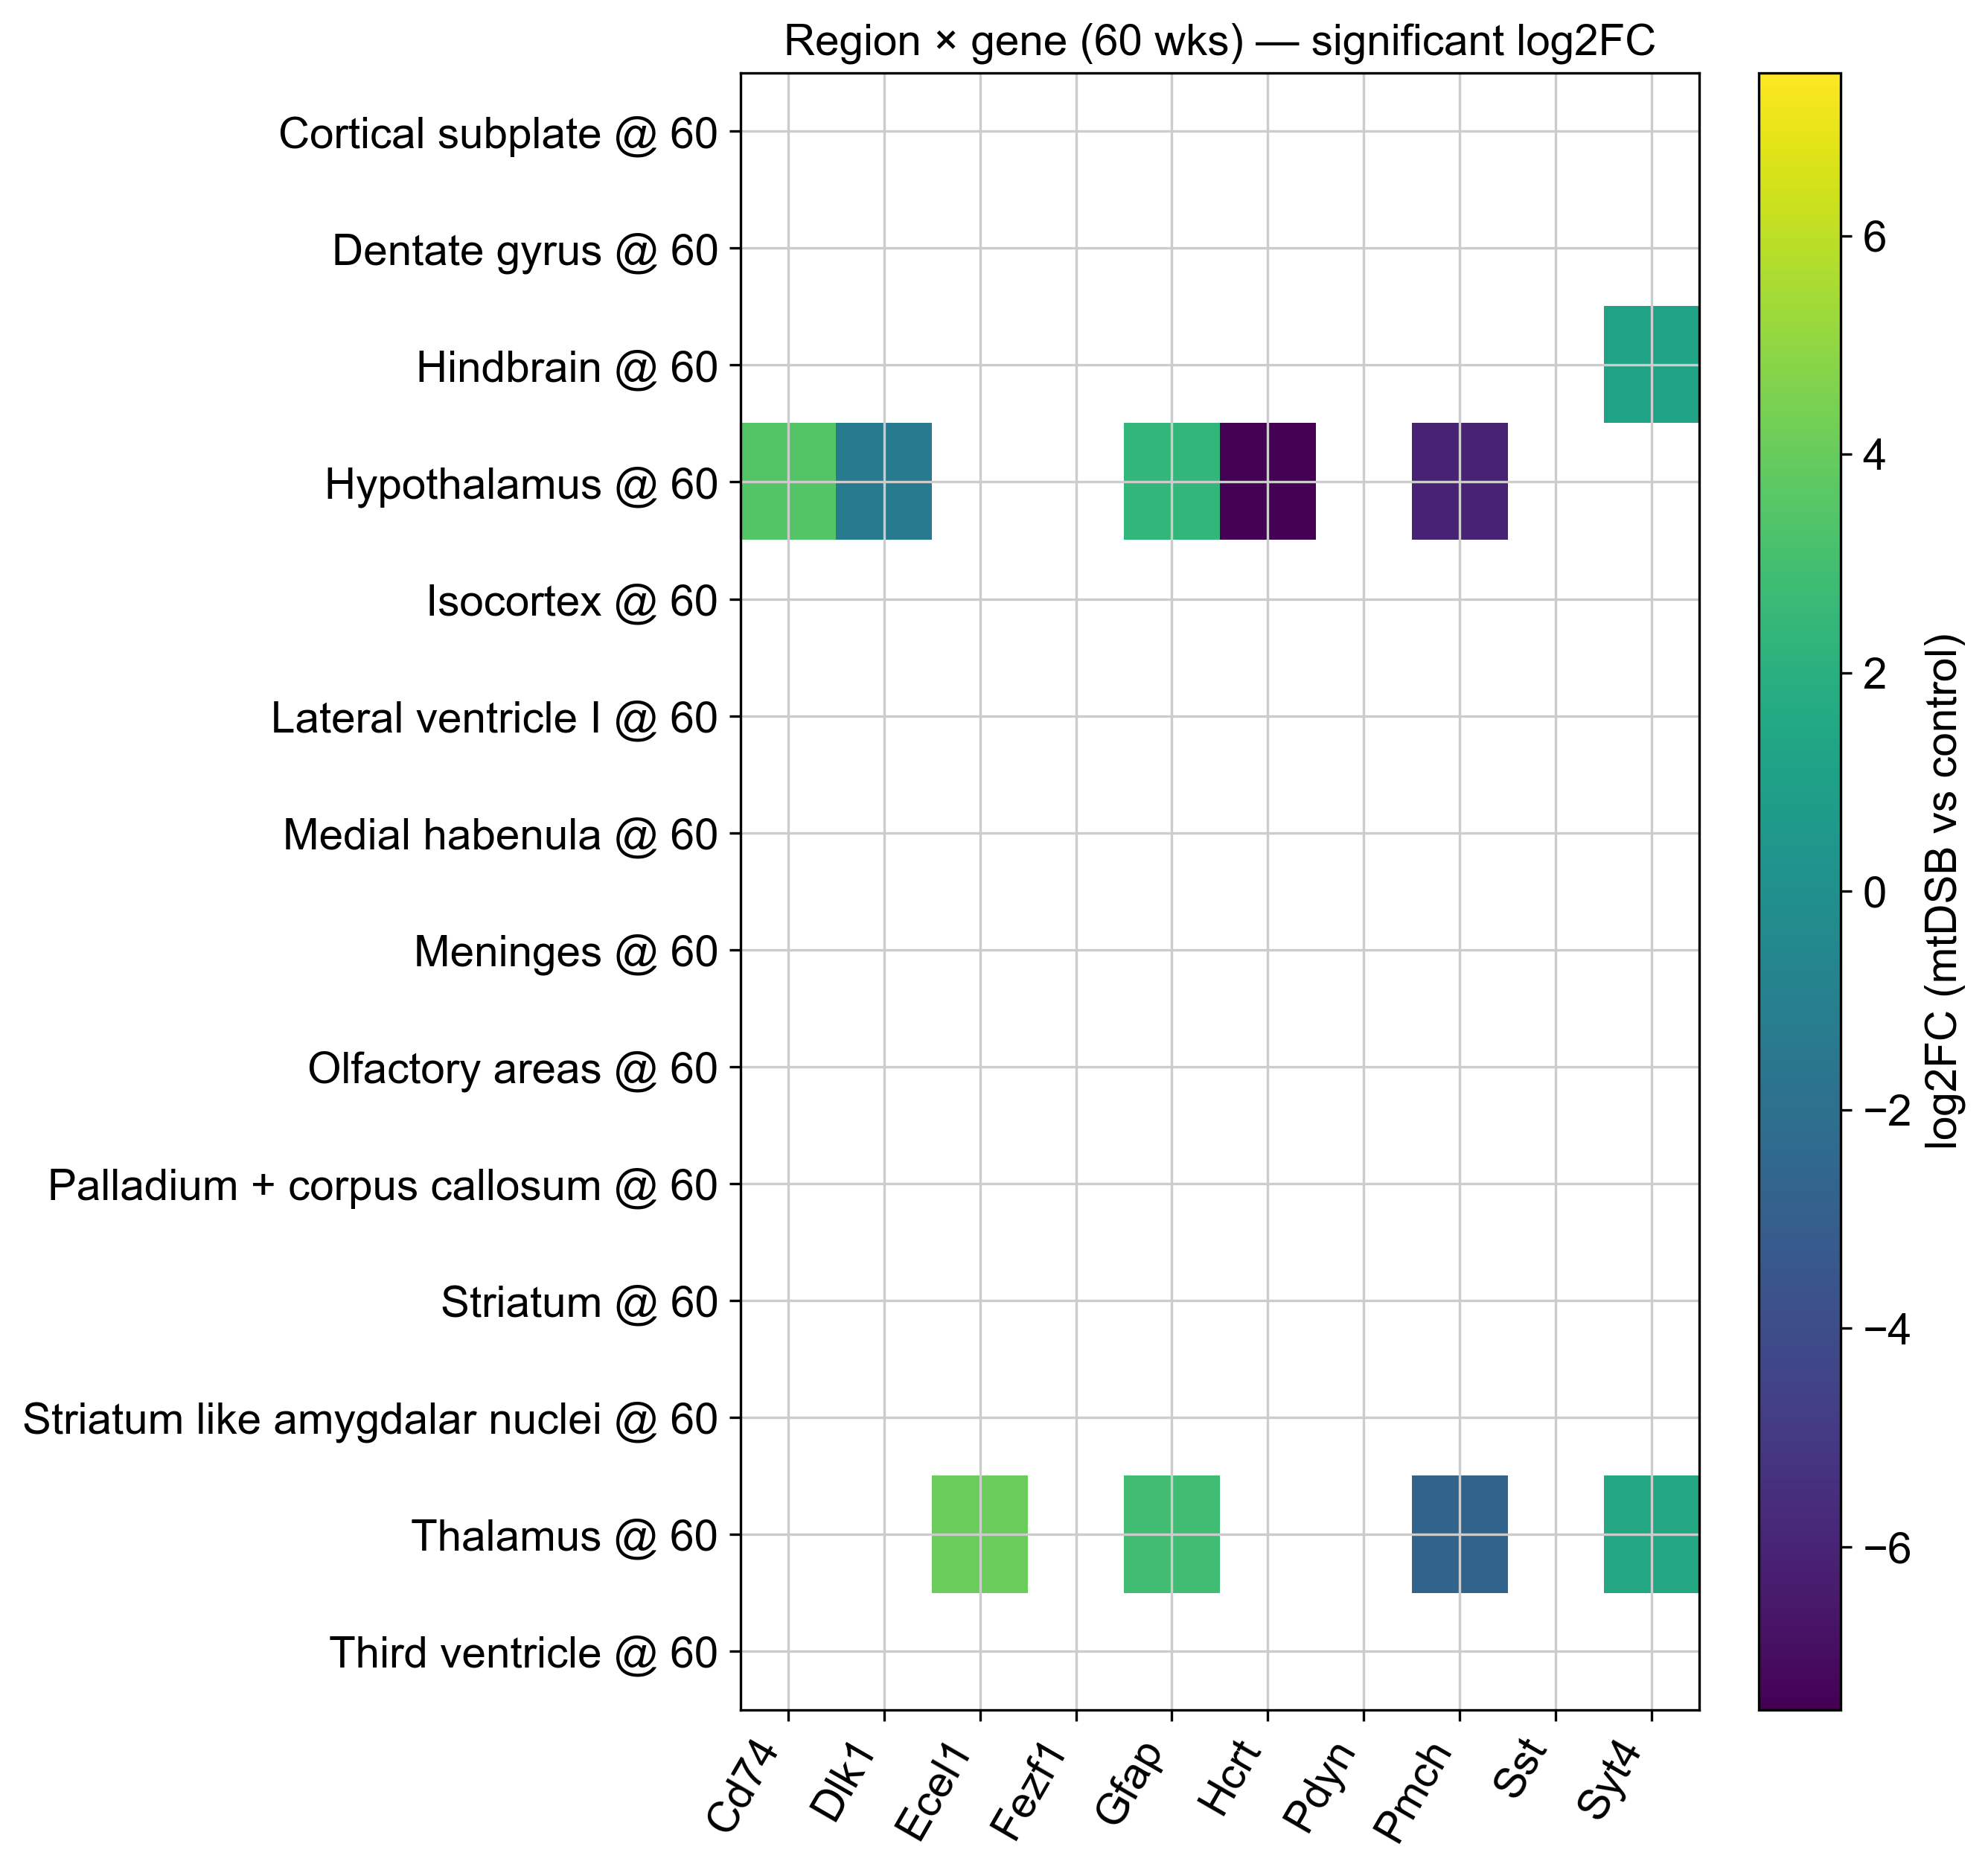

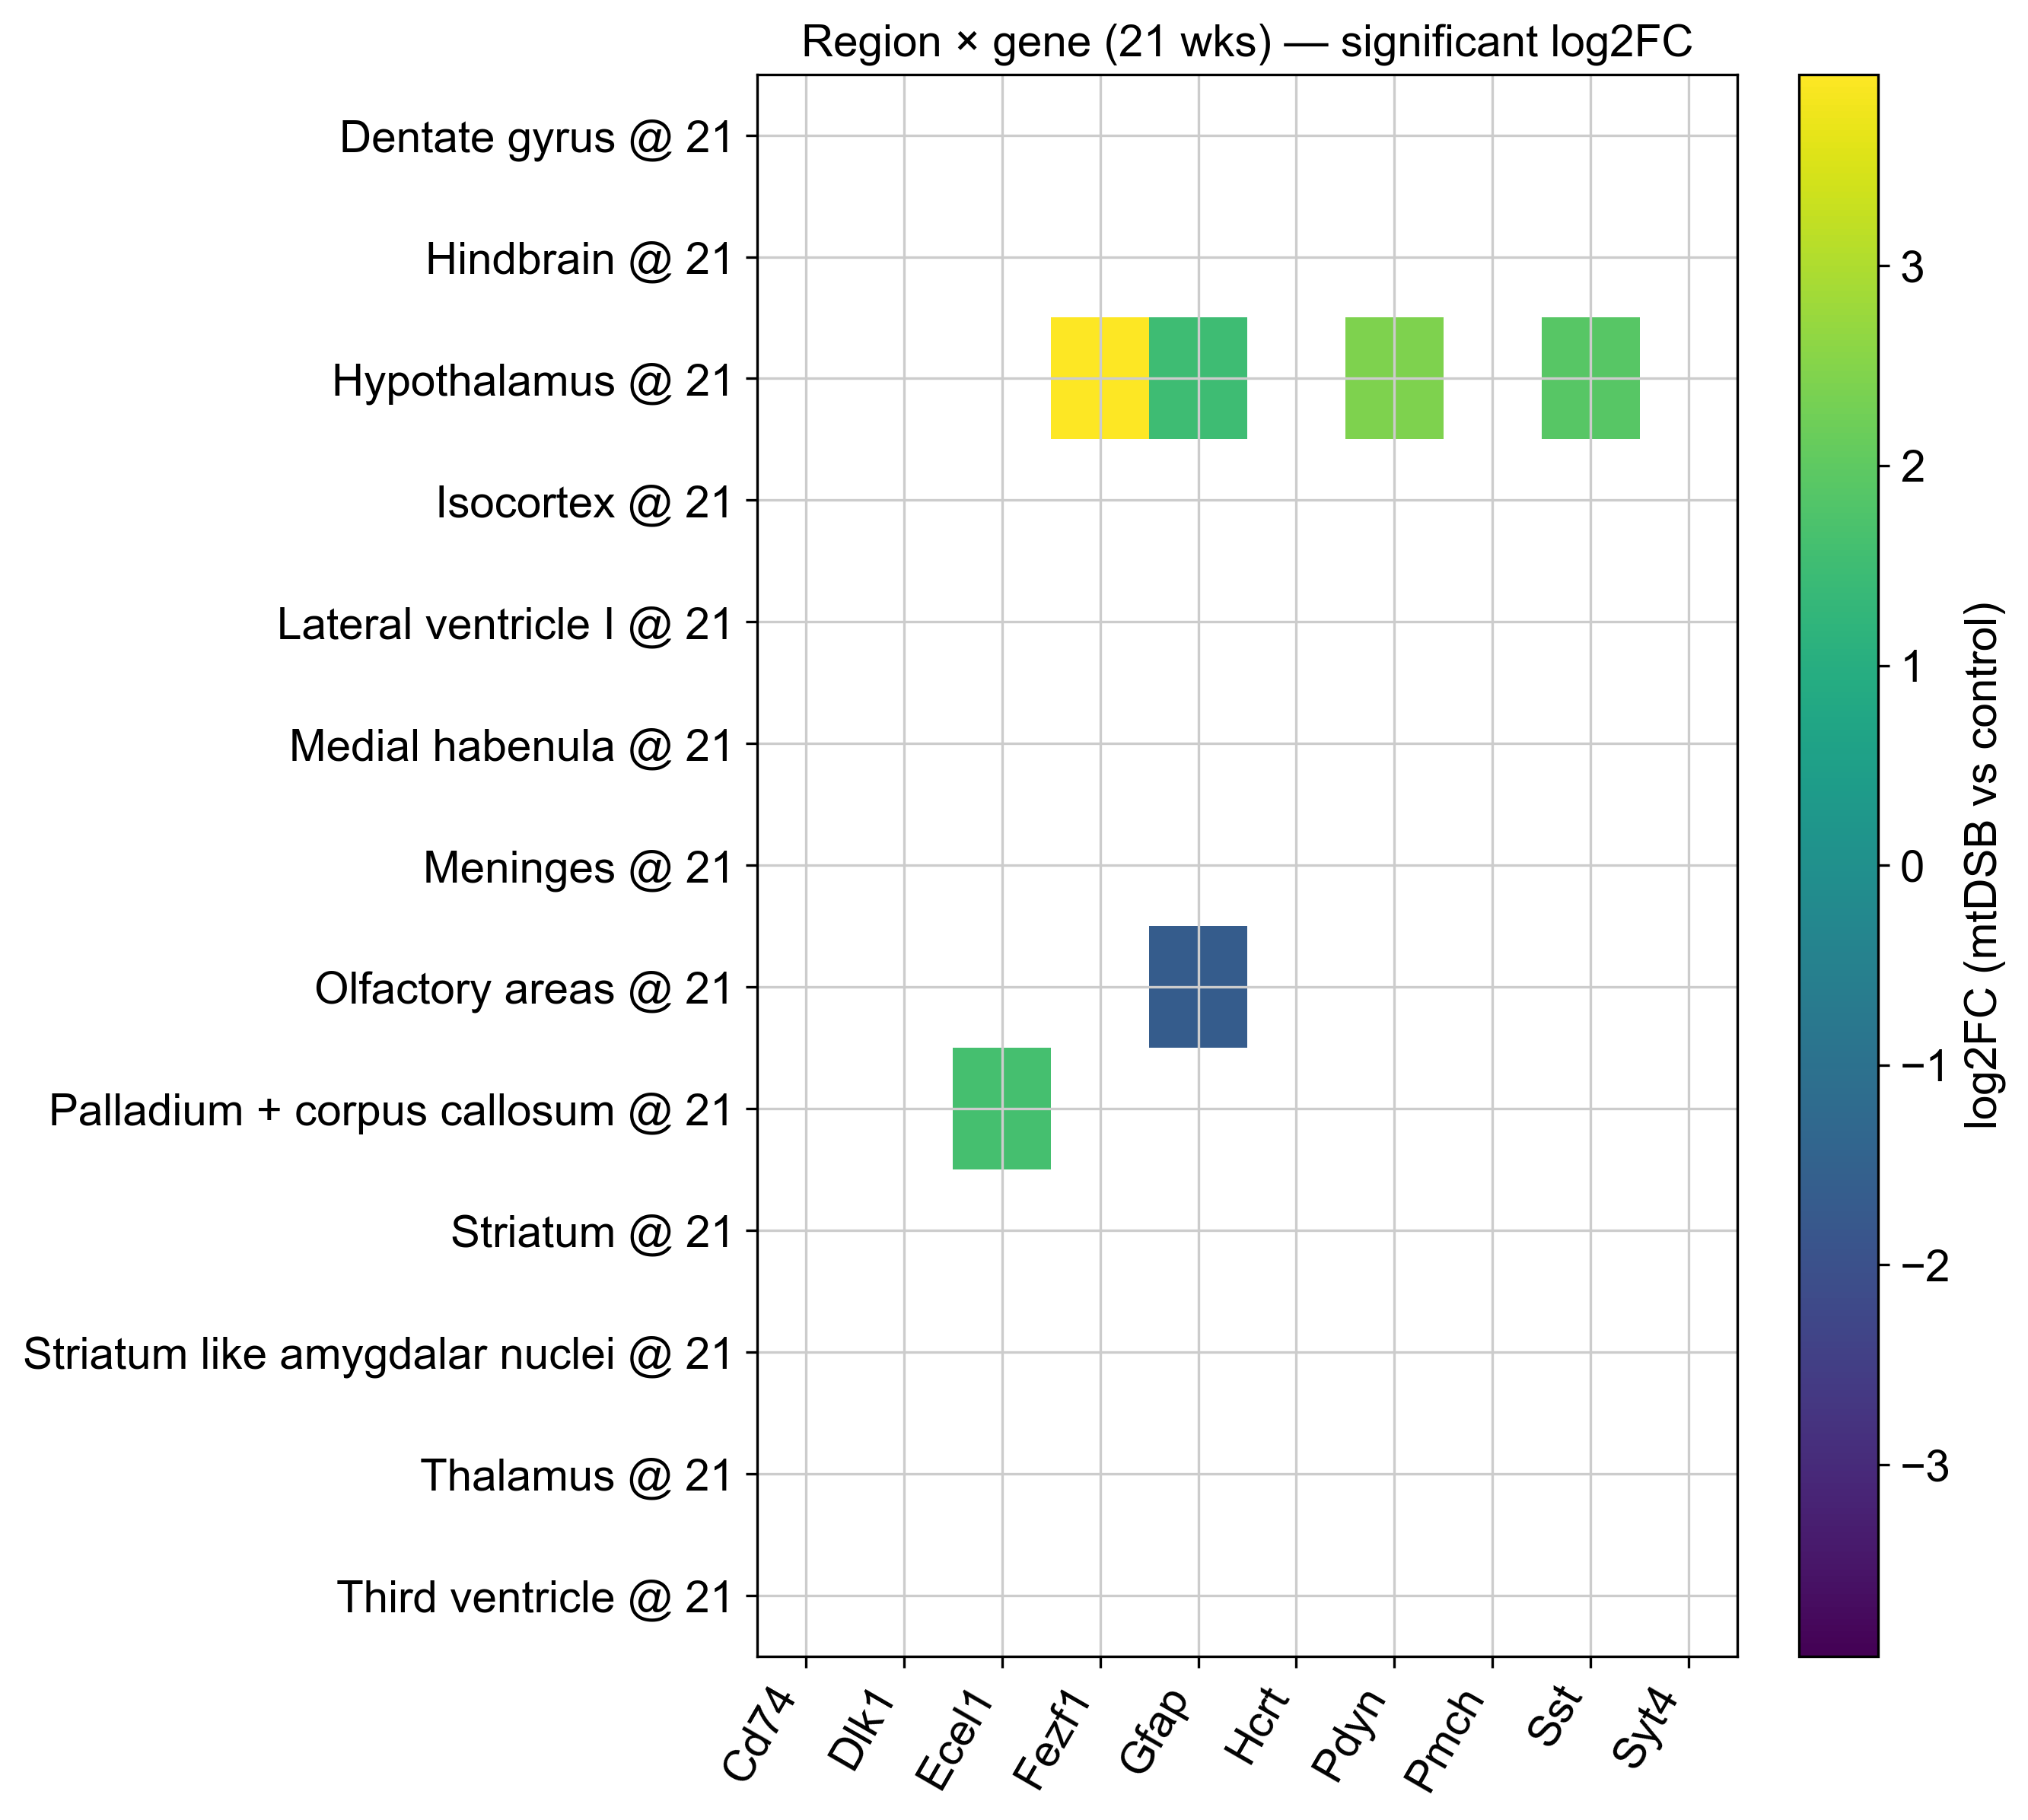

In [111]:
mat60 = region_gene_matrix(results_by_region, "Mature oligodendrocytes", gene_panel, ages=["60"], padj_thr=0.05)
mat21 = region_gene_matrix(results_by_region, "Mature oligodendrocytes", gene_panel, ages=["21"], padj_thr=0.05)

heatmap(mat60, "Region × gene (60 wks) — significant log2FC")
heatmap(mat21, "Region × gene (21 wks) — significant log2FC")

In [112]:
import os
import pandas as pd

def save_all_region_results(results_by_region, outdir="../../results_regionwise"):
    """
    Save all DE results from `results_by_region` into organized subfolders.
    Structure:
        outdir/
          └── <cell_class>/
                ├── <region>/
                │     ├── simple_effect_age_<age>.csv
                │     └── ...
                └── summary_region_impact.csv
    """
    os.makedirs(outdir, exist_ok=True)

    for cell_class, region_dict in results_by_region.items():
        cell_dir = os.path.join(outdir, cell_class.replace(" ", "_"))
        os.makedirs(cell_dir, exist_ok=True)
        print(f"\n📂 Saving {cell_class} ...")

        region_summary_rows = []

        for region, reg_data in region_dict.items():
            reg_dir = os.path.join(cell_dir, region.replace(" ", "_"))
            os.makedirs(reg_dir, exist_ok=True)

            # --- Simple effects per age (mtDSB vs control) ---
            simple_effects = reg_data.get("simple_effects", {})
            for age, df in simple_effects.items():
                if df is not None and not df.empty:
                    fname = f"simple_effect_age_{age}.csv"
                    df.to_csv(os.path.join(reg_dir, fname))
            
            # --- Region-level impact summary ---
            imp = reg_data.get("impact", {})
            for age, metrics in imp.items():
                if metrics:
                    region_summary_rows.append({
                        "region": region,
                        "age": age,
                        "n_sig": metrics.get("n_sig", np.nan),
                        "sum_neglog10q": metrics.get("sum_neglog10q", np.nan),
                    })

        # --- Save region summary table per cell_class ---
        if region_summary_rows:
            summary_df = pd.DataFrame(region_summary_rows)
            summary_df.to_csv(os.path.join(cell_dir, "summary_region_impact.csv"), index=False)

        print(f"✅ Saved regionwise results for {cell_class} to {cell_dir}")

In [115]:
save_all_region_results(results_by_region, outdir="../results/region")


📂 Saving Mature oligodendrocytes ...
✅ Saved regionwise results for Mature oligodendrocytes to ../results/region/Mature_oligodendrocytes

📂 Saving Oligodendrocytes precursor cells ...
✅ Saved regionwise results for Oligodendrocytes precursor cells to ../results/region/Oligodendrocytes_precursor_cells


In [122]:
adata.obs

View of AnnData object with n_obs × n_vars = 184678 × 5101
    obs: 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'run', 'n_genes_by_counts', 'n_counts', 'n_genes', 'leiden_0.5', 'leiden_1', 'leiden_2', 'cell_class', 'sample_id', 'age', 'sex', 'genotype', 'condition', 'cell_type'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: 'cell_class_colors', 'cell_type_colors', 'leiden', 'leiden_0.5_colors', 'leiden_1_colors', 'leiden_2_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_pca', 'X_umap', 'spatial'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'connectivities', 'distances'